Decode with SVM, post and ITI

version log:
v10- 10.15.24:
-change PCA projection vs concat matrix heatmap script to use the previously incorpotate 'averaged PCs' data, but using one sample cocnat matrix to project into that space

v11- 10.23.24
- remove averging over PCs
- adding new distance measure to use instead of mean (mahal distance)
- using data from(drop event with low peak raster)

v12- 10/27/24- added sil. score instead of centroids
- runnig with oct 26,24 output,which is 'base' raster without dropping low events

v13- 10/29/24
-adding analysiss cross-stage out of distribution testing for decoding (e.g. train on IA Error vs RS Erorr, test on IA correct vs RS Correct)

v14- 11/1/24
-adding reformatted plotting of all ensembles/decoding
v15- 11/11/24: Ran with nick spike detection settings
 11/14/25- reran with katheeln spike detection settings + reformatted spike scripts
 v16- run 11/18/24 with low thresh spike detection
 v17- run 11/24/24 to alter to remove pickup of previously created PCs, instead creating locally for viz. Now storing cosine sim in local bootstrapping vs creating for decoding runs
 v18- first merging of post/pre bin dropping in the preprocessing pipeline
 v25- add TSNE attempt\
 v27-3./13/25- transition visualization to autoencoder. add confusion matrix for misclassification
 3/18/25- add cluster quantification
 v28- added new autoencoder plot and dropped other
 v29- created new pseudobootstrap for autoencoder projections (create BxNx2 matrix and posthoc chop into pieces matching each autoencoder
 
 v30- change confusion matrices to pieplots from heatmaps/tables. Further aesthetic tuning for decoding accuracy.
 v31- fixed errors in legends. aligned colors of pie to predicted class, created fast function for plotting ensemble svm accuracy with legends
 -v32- added barplot version of piecharts. streamline DB bootstrap saving + ingestion. fixed bug with not saving torch outputs at right place.  added constraint on bootstrap to have 50/50 class split
 -v33- moved autoencoder creation and plotting to standalone script
 -v35- removed diff code (there was also a bug due to not multplying by 2, which caused values ot not be adding up to 1 for each actual data class ) 

## Setup


In [1]:
!conda info


     active environment : local_colab
    active env location : C:\Users\13car\anaconda3\envs\local_colab
            shell level : 1
       user config file : C:\Users\13car\.condarc
 populated config files : C:\Users\13car\anaconda3\.condarc
                          C:\Users\13car\.condarc
          conda version : 24.11.3
    conda-build version : 24.9.0
         python version : 3.12.3.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=skylake
                          __conda=24.11.3=0
                          __cuda=12.8=0
                          __win=0=0
       base environment : C:\Users\13car\anaconda3  (writable)
      conda av data dir : C:\Users\13car\anaconda3\etc\conda
  conda av metadata url : None
           channel URLs : https://repo.anaconda.com/pkgs/main/win-64
                          https://repo.anaconda.com/pkgs/main/noarch
                          https://repo.anaconda.com/pkgs/r/win-64
                          

In [2]:
%cd "G:\My Drive\Colab Notebooks\Function .py Storage"
%pip install --prefer-binary -r requirements.txt
import sys, os
sys.path.append(r"G:\My Drive\Colab Notebooks\Function .py Storage")
#run import modules 
from package_imports import png, np, matplotlib, plt, pd, sns, itertools, scipy, warnings, tqdm, sklearn, datetime, joblib
from custom_module_imports import * 
matplotlib.use('module://matplotlib_inline.backend_inline')#last resort explicit set
#import prebuilt modules
from scipy import stats
from textwrap import wrap
from sklearn import svm
from sklearn.model_selection import StratifiedShuffleSplit,ShuffleSplit, train_test_split
from sklearn.metrics import davies_bouldin_score
#import custom modules
from phase_enrichment_timeseries.phase_enrich_timeseries_decode import * #contains: resamp_mak e_class_obj, resample_combine_dict_of_activity_dfs
from taco_functions_module import TACO_table_feature_annotation_functions
from functools import partial
from joblib import Parallel, delayed 
from dimension_reduce import *
from matplotlib import colormaps

pd.set_option('mode.use_inf_as_na', False)
# pd.set_option('future.no_silent_downcasting', True)
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},SKLEARN ver: {sklearn.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
plt.style.use('paper_plot.mplstyle') ## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

analysis_data_to_use = '10-Dec-2024'
analysis_data_to_use_folder = '11-Dec-2024_event_fixed_stage_labels'
datasets_location = f"G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/{analysis_data_to_use_folder} Dataset Source/"
enriched_by_stage_path = f'main_datasets_complexTACO- neurons_activity by task phase_{analysis_data_to_use}.xls' #300 shuff, april 24 run
post_activity_timeseries = datasets_location + f'post_outcome_main_datasets_neurons_trial activity timeseries data_{analysis_data_to_use}_timeseries.csv'
timeseries_loc = datasets_location

print(datasets_location)
print(post_activity_timeseries)
os.getcwd()

[WinError 2] The system cannot find the file specified: 'G:\\My Drive\\Colab Notebooks\\Function .py Storage'
g:\My Drive\Colab Notebooks\Manuscript Standalone Files


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


ModuleNotFoundError: No module named 'package_imports'

#### Create new CSV storage 

In [ ]:
folder_loc = 'G:/My Drive/Colab Notebooks/Run Outputs/'
os.chdir(folder_loc)
print(f" CWD: { os.getcwd()}")
record_metadata_tag = False #this is if you are going to append the folder name for these figures, with information about the processing
metadata_tag = ""
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + metadata_tag + "/"
make_folder(folder_name)
subfolder_names= make_figtype_subfolders(folder_name)

csv_folder_most_recent = folder_loc+f"most_recent_analysis_CSV_storage/"
csv_folder_current_run =folder_loc+f"analysis_CSV_storage_{date_tag}/" 
#make current folder 
make_folder( csv_folder_most_recent)
make_folder( csv_folder_current_run)

 CWD: G:\My Drive\Colab Notebooks\Run Outputs
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_postSVM_decoding_accuracy_and_PCA_plots_21_Jul_2025/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_postSVM_decoding_accuracy_and_PCA_plots_21_Jul_2025/svg_plots/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_postSVM_decoding_accuracy_and_PCA_plots_21_Jul_2025/pdf_plots/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/figure_5_postSVM_decoding_accuracy_and_PCA_plots_21_Jul_2025/png_plots/' has been created.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/' already exists.
The folder 'G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/' already exists.


tseries


In [ ]:
#declare loc/names of files to read
os.chdir(timeseries_loc)#navigate to dataset folders
print(timeseries_loc)
print(hyper_param_dict)

#specify filenames
use_october_data = False
if use_october_data:
    print('using October 26th Nick spike data')
    analysis_data_to_use = '26-Oct-2024'
    datasets_location = r'G:\My Drive\Colab Notebooks\Sohal Lab Datasets\time-series including WT CLNZ dataset\Pre-november dataset inputs'
    enriched_by_stage_path = os.path.join(datasets_location , f'main_datasets_complexTACO- neurons_activity by task phase_{analysis_data_to_use}.xls') #300 shuff, april 24 run
    analysis_config_path = []
    post_activity_timeseries = os.path.join(datasets_location ,  f'post_outcome_main_datasets_neurons_trial sig activity_timeseries.csv')

trial_tseries_df_norm = get_normed_trial_tseries(enriched_by_stage_path,post_activity_timeseries, hyper_param_dict) #OPTIONAL- drop  timebins #drop N bins if applicable
stage_names = sorted(trial_tseries_df_norm[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) # unit_mean_tseries['mean_rate'] = unit_mean_tseries[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['unique_ID'].nunique()
subject_stage_info_df.tail()

G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/11-Dec-2024_event_fixed_stage_labels Dataset Source/
{'drop_low_responders': False, 'drop_cells_active_in_1_trial': False, 'window_to_bin': 5, 'bin_size': 0.25, 'n_sec_to_rotate': 0, 'n_pre_bin_to_drop': 8, 'n_post_end_bin_to_drop': 0, 'normalize_data': True, 'drop_subj_w_1_stage_trial': False, 'data_type': 'event_rate', 'trial_tseries_save_name': 'single_trial_post_neuron_timeseries_w_enrichment_11-Dec-2024_.csv'}
  Var1_4      Var1_5 Var1_6
0  False  bimodality      1
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
          name  mean activity
0  13_4_WT_RS1       0.024520
1  13_6_WT_RS1       0.023264
2  14_2_WT_RS1       0.021974
3   5_3_WT_RS1       0.017931
4   6_2_WT_RS1       0.015547
5   7_2_WT_RS1       0.012062
6   7_4_WT_RS1       0.015499
7   7_

,name,geno_day,task_phase_vec,unique_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",34,179,"[3, 5]",2,"[False, False]"
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",9,179,"[17, 19, 21]",3,"[True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",9,179,"[18, 20]",2,"[True, True]"
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-9, 9_3_HET_RS3-25, 9_3_HET_RS3-31...",15,179,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130]",2,179,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### Load and extract decoding CSV


In [ ]:
#### read location of decoding csv from readout
f = open(timeseries_loc+"last_decoding_run_info.txt", "r")
decode_txt = f.read()
f.close()
print(decode_txt)
decode_file = decode_txt.split(': ')[1].split('. Run')[0]
decode_scores =pd.read_parquet(timeseries_loc+ decode_file)
print(decode_scores.info())
decode_scores

latest decoding output filename: Decode enrich_unit 1000 pseudopop post_outcome_activity 31_May_2025.parquet. Run end: 31_May_2025. Data used: 11-Dec-2024_event_fixed_stage_labels
<class 'pandas.core.frame.DataFrame'>
Int64Index: 240000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   split                240000 non-null  float64       
 1   accuracy             240000 non-null  float64       
 2   num_features_used    240000 non-null  float64       
 3   num_nonzero_coef     240000 non-null  float64       
 4   train_pos_sample     240000 non-null  float64       
 5   train_neg_sample     240000 non-null  float64       
 6   test_pos_sample      240000 non-null  float64       
 7   test_neg_sample      240000 non-null  float64       
 8   true_pos             240000 non-null  float64       
 9   true_neg             240000 non-null  float64       
 10  false_pos

,split,accuracy,num_features_used,num_nonzero_coef,train_pos_sample,train_neg_sample,test_pos_sample,test_neg_sample,true_pos,true_neg,...,Phase1,Phase2,enriched_group,geno_day,train_size,k_folds,classes decoded,timebin_size,run_end_time,dataset_folder_name
0,2.5,0.99375,81.0,81.00,300.0,300.0,300.0,300.0,100.00,98.75,...,Early_IA_Correct,Early_IA_Error,Early_IA_Correct,Het CLNZ,0.75,4,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
1,2.5,0.99375,109.0,109.00,300.0,300.0,300.0,300.0,100.00,98.75,...,Early_IA_Correct,Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.75,4,Early_IA_Correct_v_Early_RS_Correct,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
2,2.5,0.95875,81.0,62.75,300.0,300.0,300.0,300.0,95.75,96.00,...,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Het CLNZ,0.75,4,Early_IA_Error_v_Early_RS_Error,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
3,2.5,0.94250,109.0,78.00,300.0,300.0,300.0,300.0,92.50,96.00,...,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Het CLNZ,0.75,4,Early_RS_Correct_v_Early_RS_Error,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
4,2.5,0.87375,109.0,88.25,300.0,300.0,300.0,300.0,89.50,85.25,...,Late_IA,Late_RS,Early_IA_Correct,Het CLNZ,0.75,4,Late_IA_v_Late_RS,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2.5,0.78125,30.0,18.00,300.0,300.0,300.0,300.0,89.25,67.00,...,Early_RS_Correct,Early_RS_Error,Late_RS,WT VEH,0.75,4,Early_RS_Correct_v_Early_RS_Error,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
29996,2.5,0.87625,42.0,42.00,300.0,300.0,300.0,300.0,79.25,96.00,...,Late_IA,Late_RS,Late_RS,WT VEH,0.75,4,Late_IA_v_Late_RS,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
29997,2.5,0.78875,42.0,36.00,300.0,300.0,300.0,300.0,78.00,79.75,...,Early_IA_Correct,Late_IA,Late_RS,WT VEH,0.75,4,Early_IA_Correct_v_Late_IA,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels
29998,2.5,0.93125,42.0,42.00,300.0,300.0,300.0,300.0,88.75,97.50,...,Early_RS_Correct,Late_RS,Late_RS,WT VEH,0.75,4,Early_RS_Correct_v_Late_RS,0.25,2025-05-31 11:00:19.773873,11-Dec-2024_event_fixed_stage_labels


In [ ]:
pop_mean_decoding = decode_scores.groupby(by = [
    'geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])['accuracy'].mean().reset_index()#.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
pop_mean_decoding[['class_0', 'class_1']]= pop_mean_decoding['classes decoded'].str.split('_v_',expand=True)
print(f" Bootstrapped over {pop_mean_decoding.pseudopop_run_num.nunique()} runs, Decoded pairs: {pop_mean_decoding['classes decoded'].unique()}")
print(pop_mean_decoding.info())
pop_mean_decoding.head()

 Bootstrapped over 1000 runs, Decoded pairs: ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Correct_v_Late_IA', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error', 'Early_RS_Correct_v_Late_RS', 'Late_IA_v_Early_RS_Correct', 'Late_IA_v_Late_RS']
Categories (8, object): ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Correct_v_Late_IA', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error', 'Early_RS_Correct_v_Late_RS', 'Late_IA_v_Early_RS_Correct', 'Late_IA_v_Late_RS']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240000 entries, 0 to 239999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   geno_day           240000 non-null  category
 1   enriched_group     240000 non-null  category
 2   classes decoded    240000 non-null  category
 3   pseudopop_run_num  240000 non-null  int64   
 

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99375,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.99250,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99375,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99375,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.98250,Early_IA_Correct,Early_IA_Error


#### Load and extract time-bin dependent decoding CSV


In [ ]:
### get timebin decoding file 
f = open(timeseries_loc+"last_time_decoding_run_info.txt", "r")
decode_txt_out_distrib = f.read()
f.close()
print(decode_txt_out_distrib)
decode_file = decode_txt_out_distrib.split(': ')[1].split('. Run')[0]
print(decode_file)

#### read location of decoding csv from readout
time_decode_scores =pd.read_parquet(timeseries_loc+ decode_file)
time_decode_scores

latest time-based decoding output filename: Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet. Run end: 31_May_2025. Data used: 11-Dec-2024_event_fixed_stage_labels
Timebin Decoding- 1000_bootstrap post_outcome_activity 31_May_2025.parquet


,pseudopop_run_num,enriched_group,Phase1,Phase2,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,classes decoded,timebin_size,run_end_time,dataset_folder_name,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.00000,-0.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.99875,3.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,0.99750,6.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,0.99875,9.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99750,12.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,9.0s to 12.0s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[12, 23]",12,23,0.0s,0.87500,3.0s,12,Late_IA_v_Early_RS_Correct,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,0.0s to 3.0s
143996,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[24, 35]",24,35,3.0s,0.94625,6.0s,12,Late_IA_v_Early_RS_Correct,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,3.0s to 6.0s
143997,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[36, 47]",36,47,6.0s,0.92750,9.0s,12,Late_IA_v_Early_RS_Correct,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,6.0s to 9.0s
143998,999,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"[48, 59]",48,59,9.0s,0.91625,12.0s,12,Late_IA_v_Early_RS_Correct,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,9.0s to 12.0s


In [ ]:
timebin_cols =  ['frame_subset','bin_start_index','bin_end_index','bin_start_str' ,'bin_end_str']
time_decode_scores = time_decode_scores.rename({"Phase1": "class_0", "Phase2": "class_1"}, axis = 1)
print(f" Bootstrapped over {time_decode_scores.pseudopop_run_num.nunique()} runs, Decoded pairs: {time_decode_scores['classes decoded'].unique()}")
time_decode_scores['bin_name'] = time_decode_scores.bin_start_str.str.cat( time_decode_scores.bin_end_str, sep = ' to ')
time_decode_scores.head()

 Bootstrapped over 1000 runs, Decoded pairs: ['Early_IA_Correct_v_Early_IA_Error' 'Early_IA_Correct_v_Early_RS_Correct'
 'Early_IA_Error_v_Early_RS_Error' 'Early_RS_Correct_v_Early_RS_Error'
 'Late_IA_v_Late_RS' 'Early_IA_Correct_v_Late_IA'
 'Early_RS_Correct_v_Late_RS' 'Late_IA_v_Early_RS_Correct']


,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size,classes decoded,timebin_size,run_end_time,dataset_folder_name,bin_name
0,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[0, 11]",0,11,-3.0s,1.00000,-0.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,-3.0s to -0.0s
1,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[12, 23]",12,23,0.0s,0.99875,3.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,0.0s to 3.0s
2,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[24, 35]",24,35,3.0s,0.99750,6.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,3.0s to 6.0s
3,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[36, 47]",36,47,6.0s,0.99875,9.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,6.0s to 9.0s
4,0,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"[48, 59]",48,59,9.0s,0.99750,12.0s,12,Early_IA_Correct_v_Early_IA_Error,0.25,2025-05-31 16:05:46.306564,11-Dec-2024_event_fixed_stage_labels,9.0s to 12.0s


#### Load and Transform out of distribution decoding result CSV

In [ ]:
?make_folder

Signature: make_folder(folder_name)
Docstring: <no docstring>
File:      g:\my drive\colab notebooks\function .py storage\helper_functions.py
Type:      function

In [ ]:
#### read location of decoding csv from readout
f = open(timeseries_loc+"last_generalize_decoding_run_info.txt", "r")
decode_txt_out_distrib = f.read()
f.close()
print(decode_txt_out_distrib)
decode_file = decode_txt_out_distrib.split(': ')[1].split('. Run')[0]
print(decode_file)
decode_out_distrib =pd.read_parquet(timeseries_loc+ decode_file)
## annotate out of distribution dataframe
decode_out_distrib['train_on'] = decode_out_distrib['class_0_train'].str.cat(decode_out_distrib['class_1_train'], sep = "_").str.replace("_", " ")
decode_out_distrib['test_on'] = decode_out_distrib['class_0_test'].str.cat(decode_out_distrib['class_1_test'], sep = "_").str.replace("_", " ")
decode_out_distrib['classes decoded'] = decode_out_distrib['train_on'].str.cat(decode_out_distrib['test_on'], sep = " v ")
decode_out_distrib['classes decoded'] = decode_out_distrib['classes decoded'].str.replace("_", " ")
# decode_out_distrib['enriched_group'] = decode_out_distrib['enriched_group']
decode_out_distrib.head()

latest generalize decoding output filename: Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet. Run end: 31_May_2025. Data used: 11-Dec-2024_event_fixed_stage_labels
Decode (Out of Distrib) 1000 pseudopop post_outcome_activity 31_May_2025.parquet


,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,pseudopop_run_num,enriched_group,geno_day,...,regularization,date_run,train_size,k_folds,timebin_size,run_end_time,dataset_folder_name,train_on,test_on,classes decoded
0,0.691250,81.0,81.0,0.417031,0.274219,0.225781,0.082969,0,Early_IA_Correct,Het CLNZ,...,l2,2025-05-31 16:06:16.834392,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...
1,0.772344,81.0,63.0,0.454219,0.318125,0.181875,0.045781,0,Early_IA_Correct,Het CLNZ,...,l2,2025-05-31 16:06:16.895296,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Error Early RS Error,Early IA Correct Early RS Correct,Early IA Error Early RS Error v Early IA Corre...
2,0.569844,81.0,81.0,0.307500,0.262344,0.237656,0.192500,0,Early_IA_Correct,Het CLNZ,...,l2,2025-05-31 16:06:16.942382,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early IA Error,Early RS Correct Early RS Error,Early IA Correct Early IA Error v Early RS Cor...
3,0.651250,81.0,57.0,0.381406,0.269844,0.230156,0.118594,0,Early_IA_Correct,Het CLNZ,...,l2,2025-05-31 16:06:16.989851,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early RS Correct Early RS Error,Early IA Correct Early IA Error,Early RS Correct Early RS Error v Early IA Cor...
4,0.560938,29.0,29.0,0.276719,0.284219,0.215781,0.223281,0,Early_IA_Correct,Het VEH,...,l2,2025-05-31 16:06:17.055557,0.75,4,0.25,2025-05-31 16:46:23.330643,11-Dec-2024_event_fixed_stage_labels,Early IA Correct Early RS Correct,Early IA Error Early RS Error,Early IA Correct Early RS Correct v Early IA E...


In [ ]:
# ## import necessary data types
# neuron_enrichment =  trial_tseries_df_norm.groupby(['name', 'geno_day', 'neuron_ID'])[stage_names].mean().reset_index()
# phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + ['name', 'geno_day']].groupby(by = ['name', 'geno_day']).sum().reset_index()
# ##option 2- run the real pseudopop draw creaiton scirpt wonce again
# trial_list_by_dataset= subject_stage_info_df.loc[:,['name', 'geno_day', 'task_phase_vec', 'trial_num', 'count_of_trials']]
# ##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
# trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
# enrich_unit_ID_by_name_df = subject_stage_info_df.loc[:,['name', 'geno_day', 'task_phase_vec', 'unique_ID']]
# dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['name'].unique().reset_index()
# ##create class matrix store
# class_matrix_store = make_dataset_matrix_store_only(stage_names, trial_tseries_df_norm, "unique_ID",
#                                                     enrich_unit_ID_by_name_df, numeric_col, trial_list_by_dataset, dataset_name_by_geno_day,
#                                                     phase_enrichment_by_subj)

In [ ]:
os.getcwd()

'G:\\My Drive\\Colab Notebooks\\Sohal Lab Datasets\\time-series including WT CLNZ dataset\\11-Dec-2024_event_fixed_stage_labels Dataset Source'

In [ ]:
def save_metadata_record(last_run_metadata_record:pd.DataFrame, metadata_record_filename:str, save_loc:str):
    #write filename to dF
    
    if not os.path.exists(metadata_record_filename):    #create locally then save
        print(f"creating autoencoder versioning file: {metadata_record_filename}")
        last_run_metadata_record.to_csv(metadata_record_filename,index = False)
    else: #load existing and add to it 
        print(f"Loading autoencoder versioning file: {metadata_record_filename}")
        metadata_record= pd.read_csv(metadata_record_filename)
        metadata_record = pd.concat([metadata_record, last_run_metadata_record]) #join prev df with latest DF
        #save multiple backups 
        # metadata_record.to_csv(metadata_record_filename) 
        metadata_record.to_csv(save_loc + metadata_record_filename)
        metadata_record.to_csv(csv_folder_most_recent +metadata_record_filename)
        metadata_record.to_csv(csv_folder_current_run + metadata_record_filename)


#### plot all embeddings

In [ ]:
run_latent_embedding_sample= False

ensemble_plot = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error']
geno_plot =  geno_order
decode_plot = ['Early_IA_Correct_v_Early_IA_Error', 'Early_IA_Correct_v_Early_RS_Correct', 'Early_IA_Error_v_Early_RS_Error', 'Early_RS_Correct_v_Early_RS_Error']
run_info_list = []

In [ ]:
autoencoder_record = 'last_autoencoder_run_info.txt'
autoencoder_run_versions = f"autoencoder project- run version record.csv"
resample_type_str = {True: f"Project Train Data", False: f"Project New Data"}

#save files based on conditions
if run_latent_embedding_sample:
    latent_embed_sample = pd.concat(run_info_list)
    latent_embed_sample["labels"]= np.where(latent_embed_sample["labels"] == 0.0,latent_embed_sample["class_0"], latent_embed_sample["class_1"])
    #save embed record
    autoencoder_project_filename = f"Autoencoder_latent_space_run_{date_tag}_{n_frames_to_draw}Sample_{numEpochs}Epoch_{resample_type_str[test_on_train]}"
    latent_embed_sample.to_parquet(autoencoder_project_filename, compression='snappy')
    ## save loc of current encoder
    f = open(autoencoder_record, "w")
    autoencode_run_info_str = f"latest autoencoder output filename: {autoencoder_project_filename}. Run end: {date_tag}. Data used: {analysis_data_to_use_folder}"
    f.write(autoencode_run_info_str)
    f.close()
    print(autoencode_run_info_str)
    ## DATA VERSIONING #create run information df
    run_info = {'run_date': date_tag, 
                'run_dataset_used': analysis_data_to_use_folder,
                'n_epoch': numEpochs,
                'n_class_frames':n_frames_to_draw,
                'ensembles_ran': [ensemble_plot],
                'classes_ran': [decode_plot],
                'autoencoder_project_filename':autoencoder_project_filename,
                'test_on_train': test_on_train,
                'model_storage_loc': torch_model_storage,
               }
    run_df_general = pd.DataFrame.from_dict(run_info)
    # #write filename to dF
    save_metadata_record(last_run_metadata_record=run_df_general, 
                         metadata_record_filename=autoencoder_run_versions,
                         save_loc=folder_name)

else: #if you already have an autoencoder result to open
    load_txt = False
    run_record= pd.read_csv(autoencoder_run_versions)
    if load_txt:
        f = open(autoencoder_record, "r")
        autoencode_run_txt = f.read()
        autoencoder_project_filename = autoencode_run_txt.split(': ')[1].split('. Run')[0]
        print(f"loading autoencoder filename: {autoencoder_project_filename}")
    else: #else, take from last row of run record
        autoencoder_project_filename =run_record.file_name.iloc[-1]
    print(f"reading: {autoencoder_project_filename}")
    latent_embed_sample =pd.read_parquet(timeseries_loc+ autoencoder_project_filename)
latent_embed_sample


reading: Autoencoder_latent_space_run_17_Jun_2025_500Sample_50Epoch__Embed New Data


,embed_1,embed_2,labels,classes_decoded,geno_day,ensemble,class_0,class_1,n_frames,num_epochs,mean_loss,n_cells,dropout,test_on_train,date_run
0,-0.115083,-0.207826,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,109,50,0.059056,109,0.05,False,17_Jun_2025
1,0.249411,0.344273,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,109,50,0.059056,109,0.05,False,17_Jun_2025
2,-0.027666,0.168371,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,109,50,0.059056,109,0.05,False,17_Jun_2025
3,-0.187396,-0.114856,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,109,50,0.059056,109,0.05,False,17_Jun_2025
4,-0.150540,-0.132027,Early_RS_Correct,Early_IA_Correct_v_Early_RS_Correct,WT VEH,Early_IA_Correct,Early_IA_Correct,Early_RS_Correct,109,50,0.059056,109,0.05,False,17_Jun_2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.072633,0.082026,Late_IA,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,105,50,0.074819,105,0.05,False,17_Jun_2025
496,-0.070683,0.110573,Late_IA,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,105,50,0.074819,105,0.05,False,17_Jun_2025
497,0.334449,-0.360665,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,105,50,0.074819,105,0.05,False,17_Jun_2025
498,0.288819,-0.250436,Late_IA,Early_IA_Correct_v_Late_IA,Het postCLNZ,Late_IA,Early_IA_Correct,Late_IA,105,50,0.074819,105,0.05,False,17_Jun_2025


In [ ]:
run_record.file_name.iloc[-1]

'Autoencoder_latent_space_run_17_Jun_2025_500Sample_50Epoch__Embed New Data'

In [ ]:
run_record.tail()

,run_date,run_dataset_used,n_epoch,n_class_frames,ensembles_ran,classes_ran,file_name,test_on_train,model_locations,lr
21,10_Jun_2025,11-Dec-2024_event_fixed_stage_labels,50,500,"['Early_IA_Correct', 'Early_RS_Correct', 'Earl...","['Early_IA_Correct_v_Early_IA_Error', 'Early_I...",Autoencoder_latent_space_run_10_Jun_2025_500Sa...,False,NaN,NaN
22,13_Jun_2025,11-Dec-2024_event_fixed_stage_labels,50,500,"['Early_IA_Correct', 'Early_RS_Correct', 'Earl...","['Early_IA_Correct_v_Early_IA_Error', 'Early_I...",Autoencoder_latent_space_run_13_Jun_2025_500Sa...,False,torch_model_storage_13_Jun_2025\,NaN
23,16_Jun_2025,11-Dec-2024_event_fixed_stage_labels,50,500,"['Early_IA_Correct', 'Early_RS_Correct', 'Earl...","['Early_IA_Correct_v_Early_IA_Error', 'Early_I...",Autoencoder_latent_space_run_16_Jun_2025_500Sa...,False,torch_model_storage_16_Jun_2025\,NaN
24,17_Jun_2025,11-Dec-2024_event_fixed_stage_labels,50,500,"['Early_IA_Correct', 'Early_RS_Correct', 'Earl...","['Early_IA_Correct_v_Early_IA_Error', 'Early_I...",Autoencoder_latent_space_run_17_Jun_2025_500Sa...,False,torch_model_storage_17_Jun_2025\,NaN
25,17_Jun_2025,11-Dec-2024_event_fixed_stage_labels,50,500,"['Early_IA_Correct', 'Early_RS_Correct', 'Earl...","['Early_IA_Correct_v_Early_IA_Error', 'Early_I...",Autoencoder_latent_space_run_17_Jun_2025_500Sa...,False,torch_model_storage_17_Jun_2025\,0.0125


The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\_21_Jul_2025\' has been created.


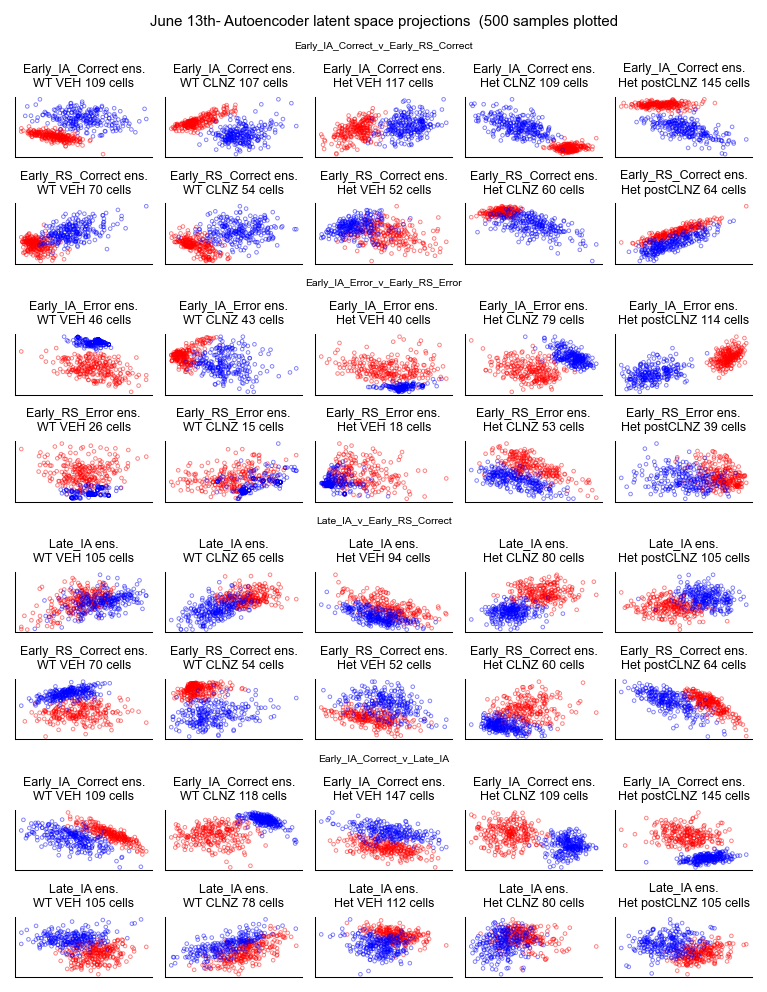

In [ ]:
plot_all_embeddings= True
if plot_all_embeddings:
    fig = plt.figure(figsize = (5,6.5), layout = 'constrained')
    ##set plot params
    plot_df = latent_embed_sample
    compared_col = 'classes_decoded'
    ens_col = 'ensemble'
    genos_used = plot_df['geno_day'].unique()
    subfigs = fig.subfigures(len(plot_df[compared_col].unique()),1,
                             wspace = 0.01, hspace = 0.01)
    #Loop over all combinations
    for r_count, comparison in enumerate(plot_df[compared_col].unique()):
        df_comparison = plot_df.loc[(plot_df[compared_col]== comparison),:]
        
        subfigs[r_count].suptitle(f"{comparison}", fontsize = 'small')
        
        s_fig_ax = subfigs[r_count].subplots(2,len(genos_used))
            
        for c_count, ensemble in enumerate(df_comparison[ens_col].unique()):
            df_ens_comparison = df_comparison.loc[df_comparison[ens_col]== ensemble, : ]
            
            for g_count, g in enumerate(genos_used):
                ax = s_fig_ax[c_count,g_count]
                #get info about current panel 
                df_ens_comparison_geno = df_ens_comparison.loc[(df_ens_comparison.geno_day == g),:]
                n_units = df_ens_comparison_geno.n_cells.unique()[0]
                plot_labels =  df_ens_comparison_geno.labels.unique()
                #plot projection
                class_1_data =  df_ens_comparison_geno.loc[ df_ens_comparison_geno.labels== plot_labels[0],:]
                class_2_data =   df_ens_comparison_geno.loc[ df_ens_comparison_geno.labels== plot_labels[1],:]
                alpha =.5
                line_width = 0.45
                n_to_plot= 500 #NEW- how many points to plot
                sc = sns.scatterplot(data =class_1_data.iloc[0:n_to_plot,:],ax =ax, x= "embed_1", y= "embed_2",  palette=['red'],hue= 'labels',legend = False, s= 3, alpha = alpha, linewidth = line_width,edgecolor = 'red', marker = 'o')
                sc = sns.scatterplot(data =class_2_data.iloc[0:n_to_plot,:],ax =ax, x= "embed_1", y= "embed_2",  palette=['blue'],hue= 'labels',legend = False, s= 3, alpha = alpha,linewidth = line_width,edgecolor = 'blue', marker = 'o')
                [x.set_facecolor('none') for x in ax.get_children() if type(x)==matplotlib.collections.PathCollection]
                #plot centroids
                set_ax_title_xlabel_ylabel(ax, label_dict = {'title': f"{ensemble} ens.\n{g} {n_units} cells",
                                                             'ylabel': None, 'xticks': [], 'yticks':[], 'xlabel':None})
    ##save fig
    fig_name = f"June 13th- Autoencoder latent space projections "
    fig.suptitle(fig_name + f" ({n_to_plot} samples plotted")
    save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_4', filetypes_to_save = ['png'])

In [ ]:
saved_model_storage = run_record.model_locations.iloc[-1] #get file location of last known run  
print(saved_model_storage)
print(os.getcwd())
print("\\".join([timeseries_loc,saved_model_storage]))

torch_model_storage_17_Jun_2025\
G:\My Drive\Colab Notebooks\Sohal Lab Datasets\time-series including WT CLNZ dataset\11-Dec-2024_event_fixed_stage_labels Dataset Source
G:/My Drive/Colab Notebooks/Sohal Lab Datasets/time-series including WT CLNZ dataset/11-Dec-2024_event_fixed_stage_labels Dataset Source/\torch_model_storage_17_Jun_2025\


## Plotting Figures- Summary figures

#### Plot SVM accuracy for all class comparisons

In [ ]:
def plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col, decoder_comparison, ax_plot):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, for all ensemble groups ued for decoding''' 
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison),:]
    plot_params = {'data':plot_df, 'dodge': 0.4, 'markers': 'o','orient':'v', 'x': 'enriched_group', 'y':'accuracy', 'order':phase_list_IA_RS_chrono, 'errorbar': ('pi', 95), **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    set_ax_title_xlabel_ylabel(ax_plot, {'title':f'Ensemble decoding:\n {decoder_comparison}', 
                                         'ylim': [0.4, 1.2],'xlabel': None, 'ylabel': 'Mean accuracy', 'legend_false':True})#adjust plot information
    ## ax level changes
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, 
                                                           test_name = 'cohen_d',detect_error_bar = True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.set_yticks([0.5, 0.75,  1.0])
    return posthoc_df

In [ ]:
pop_mean_decoding

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99375,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.99250,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99375,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99375,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.98250,Early_IA_Correct,Early_IA_Error
...,...,...,...,...,...,...,...
239995,WT VEH,Late_RS,Late_IA_v_Late_RS,995,0.87875,Late_IA,Late_RS
239996,WT VEH,Late_RS,Late_IA_v_Late_RS,996,0.87250,Late_IA,Late_RS
239997,WT VEH,Late_RS,Late_IA_v_Late_RS,997,0.88000,Late_IA,Late_RS
239998,WT VEH,Late_RS,Late_IA_v_Late_RS,998,0.85625,Late_IA,Late_RS


Saved 5_SUPP_ all in distrib decoding ensemble accuracy_posthoc all ensembles + comparisons_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 5_SUPP_ all in distrib decoding ensemble accuracy_posthoc all ensembles + comparisons_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/5_SUPP_ all in distrib decoding ensemble accuracy_posthoc all ensembles + comparisons_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/5_SUPP_ all in distrib decoding ensemble accuracy_posthoc all ensembles + comparisons_text_21_Jul_2025.txt


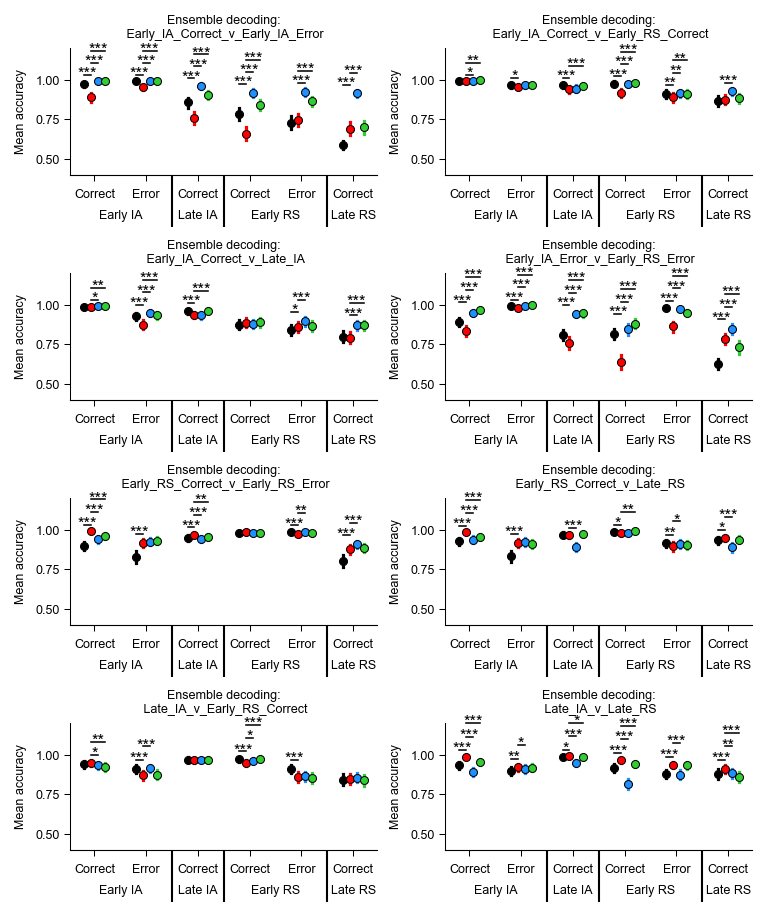

In [ ]:
## iterate over all possible combinations
decoding_col = 'classes decoded'
comparison_list = pop_mean_decoding[decoding_col].unique()
figsize = (5,6)
fig_n_rows = int(np.ceil(len(comparison_list)/2))
fig_all_decode_pairs, ax_array = plt.subplots(nrows = fig_n_rows, ncols = 2, figsize = figsize, layout = 'constrained')
posthoc_list  = [] 
for count, decoder_comparison in enumerate(comparison_list):    #set plot info ## iterate over subfigures
    ax_plot = ax_array.flat[count]
    posthoc = plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col, decoder_comparison, ax_plot)
    posthoc_list.append(posthoc.assign(comparison = decoder_comparison))

#save posthoc
fig_name = f"SUPP_ all in distrib decoding ensemble accuracy"
posthoc_csv = pd.concat(posthoc_list) # av_cosine_sim_posthoc.loc[:, ['group_1_mean','group_1_sem','group_2_mean','group_2_sem']] = av_cosine_sim_posthoc.loc[:, ['group_1_mean','group_1_sem','group_2_mean','group_2_sem']].round(4)
save_plot_record_as_csv_txt(posthoc_csv,folder_pref:="5",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="posthoc all ensembles + comparisons",
                            txt_suffix="posthoc all ensembles + comparisons_text")


In [ ]:
plot_df = pop_mean_decoding[pop_mean_decoding['classes decoded'] == comparison_list[0]]
plot_df

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99375,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.99250,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99375,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99375,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.98250,Early_IA_Correct,Early_IA_Error
...,...,...,...,...,...,...,...
232995,WT VEH,Late_RS,Early_IA_Correct_v_Early_IA_Error,995,0.60125,Early_IA_Correct,Early_IA_Error
232996,WT VEH,Late_RS,Early_IA_Correct_v_Early_IA_Error,996,0.56750,Early_IA_Correct,Early_IA_Error
232997,WT VEH,Late_RS,Early_IA_Correct_v_Early_IA_Error,997,0.58625,Early_IA_Correct,Early_IA_Error
232998,WT VEH,Late_RS,Early_IA_Correct_v_Early_IA_Error,998,0.60500,Early_IA_Correct,Early_IA_Error


In [ ]:
#save as txt
output_file = csv_folder_current_run + fig_name + f"_posthoc_results_text_{date_tag}.txt"
write_posthoc_table_to_txt(posthoc_csv, output_file)
write_posthoc_table_to_txt(posthoc_csv, csv_folder_most_recent + fig_name + f"_posthoc_results_text_{date_tag}.txt")

Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/SUPP_ all in distrib decoding ensemble accuracy_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/SUPP_ all in distrib decoding ensemble accuracy_posthoc_results_text_21_Jul_2025.txt


In [ ]:
f = open(timeseries_loc+"last_decoding_run_info_single_subject.txt", "r")
decode_subj = f.read()
f.close()
print(decode_subj)
decode_file = decode_subj.split(': ')[1].split('. Run')[0]
print(decode_file)

#### read location of decoding csv from readout
decode_subj =pd.read_parquet(timeseries_loc+ decode_file)
decode_subj

latest decoding output filename: Decode single Subject enrich_unit 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet. Run end: 28_Jan_2025. Data used: 11-Dec-2024_event_fixed_stage_labels
Decode single Subject enrich_unit 1000 pseudopop post_outcome_activity 28_Jan_2025.parquet


,pseudopop_run_num,subject_name,Phase2,Phase1,enriched_group,geno_day,mean_acc,mean_precision,mean_recall,classes decoded,timebin_size,run_end_time,dataset_folder_name
0,0,13_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.89500,0.848361,0.962791,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
1,0,13_8_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.77000,0.761062,0.873096,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
2,0,15_1_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.95000,0.934579,1.000000,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
3,0,7_6_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.84125,0.769231,0.969388,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
4,0,9_3_HET_RS2,Early_IA_Error,Early_IA_Correct,Early_IA_Correct,Het CLNZ,0.91375,0.871795,0.971429,Early_IA_Correct_v_Early_IA_Error,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67995,999,5_3_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.50125,0.600000,0.163366,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
67996,999,6_2_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.52250,0.502564,1.000000,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
67997,999,7_2_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.52625,1.000000,0.060000,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels
67998,999,7_4_WT_RS1,Early_RS_Correct,Late_IA,Late_RS,WT VEH,0.62250,0.848101,0.313084,Late_IA_v_Early_RS_Correct,0.25,2025-01-28 16:56:00.629001,11-Dec-2024_event_fixed_stage_labels


In [ ]:
#swarm plto with eahc point being mean of subj 
subj_mean_decode = decode_subj.groupby(by = ['subject_name', 'enriched_group', 'classes decoded', 'geno_day'],as_index=False)['mean_acc'].mean().dropna()
subj_mean_decode= subj_mean_decode.loc[np.logical_not(subj_mean_decode.geno_day=="WT CLNZ"), :]
subj_mean_decode.geno_day = subj_mean_decode.geno_day.astype(str)
subj_mean_decode

,subject_name,enriched_group,classes decoded,geno_day,mean_acc
6,10_3_HET_RS1,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,Het VEH,0.816784
11,10_3_HET_RS1,Early_IA_Correct,Early_IA_Correct_v_Late_IA,Het VEH,0.756256
21,10_3_HET_RS1,Early_IA_Correct,Early_RS_Correct_v_Early_RS_Error,Het VEH,0.846422
26,10_3_HET_RS1,Early_IA_Correct,Early_RS_Correct_v_Late_RS,Het VEH,0.888329
31,10_3_HET_RS1,Early_IA_Correct,Late_IA_v_Early_RS_Correct,Het VEH,0.706374
...,...,...,...,...,...
8377,9_3_HET_RS3,Late_RS,Early_IA_Error_v_Early_RS_Error,Het postCLNZ,0.512381
8382,9_3_HET_RS3,Late_RS,Early_RS_Correct_v_Early_RS_Error,Het postCLNZ,0.516420
8387,9_3_HET_RS3,Late_RS,Early_RS_Correct_v_Late_RS,Het postCLNZ,0.594046
8392,9_3_HET_RS3,Late_RS,Late_IA_v_Early_RS_Correct,Het postCLNZ,0.511077


In [ ]:
subj_mean_decode.geno_day.unique()

array(['Het VEH', 'Het CLNZ', 'Het postCLNZ', 'WT VEH'], dtype=object)

In [ ]:
plot_subj_decode_acc = False
if plot_subj_decode_acc:
    figsize = (5,6)
    fig_n_rows = int(np.ceil(len(comparison_list)/2))
    fig_all_decode_pairs, ax_array = plt.subplots(nrows = fig_n_rows, ncols = 2, figsize = figsize, layout = 'constrained')
    
    for comparison_count, decoder_comparison in enumerate(subj_mean_decode['classes decoded'].unique()):
        ax = ax_array.flat[comparison_count]
        df_curr = subj_mean_decode.loc[subj_mean_decode[decoding_col]== decoder_comparison,:]
        plot_params = {'data': df_curr,  'x': 'enriched_group', 'y':'mean_acc','hue': 'geno_day', 'palette':color_list, 'hue_order': geno_order}
        sc = sns.stripplot(ax = ax,**plot_params,s=3, alpha=0.3, dodge = True  )#make cosine sim plot itself
        s_point = sns.pointplot(ax = ax, linestyles = ['none', 'none', 'none', 'none'], dodge = 0.4,  **plot_params)
        set_ax_title_xlabel_ylabel(ax = ax, label_dict = {'title':f"Decode: {decoder_comparison}\n Bootstrap on each mouse", 'xlabel': None, 'ylim': [0.45, 1], 'ylabel': 'Avg. Bootstrap Accuracy', 'legend_false':True})
        ax_add_stage_names_and_outline_points(ax)
        ax.axhline(0.5)
    
    #supp
    
    fig_name = f"SUPP_ bootstrap individual subj-decode accuracy by ensemble"
    save_fig_as_filetype_list(fig_all_decode_pairs, fig_name , subfolder_names, [ 'pdf', 'png'])
    ##save fig
    save_fig_as_filetype_list(fig_all_decode_pairs, fig_name , subfolder_names, [ 'pdf', 'png'])
    save_fig_in_main_fig_dir(fig_all_decode_pairs, fig_name= fig_name, folder_key='s_4', filetypes_to_save = ['png'])


In [ ]:
print(matplotlib.__version__)


3.7.0


In [ ]:
#compare real to bootstrap
subj_geno_mean = subj_mean_decode.groupby(by = [ 'enriched_group', 'classes decoded', 'geno_day'],as_index = False)['mean_acc'].mean()
subj_geno_mean

,enriched_group,classes decoded,geno_day,mean_acc
0,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het CLNZ,0.872998
1,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het VEH,0.795767
2,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het postCLNZ,0.911324
3,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,WT VEH,0.798730
4,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,Het CLNZ,0.873543
...,...,...,...,...
187,Late_RS,Late_IA_v_Early_RS_Correct,WT VEH,0.575894
188,Late_RS,Late_IA_v_Late_RS,Het CLNZ,0.660831
189,Late_RS,Late_IA_v_Late_RS,Het VEH,0.650371
190,Late_RS,Late_IA_v_Late_RS,Het postCLNZ,0.622435


In [ ]:
ppop_geno_mean = pop_mean_decoding.groupby(by = [ 'enriched_group', 'classes decoded', 'geno_day'],as_index = False)['accuracy'].mean()
ppop_geno_mean

,enriched_group,classes decoded,geno_day,accuracy
0,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het CLNZ,0.991505
1,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het VEH,0.891231
2,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het postCLNZ,0.993261
3,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,WT CLNZ,0.963724
4,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,WT VEH,0.971587
...,...,...,...,...
235,Late_RS,Late_IA_v_Late_RS,Het CLNZ,0.883915
236,Late_RS,Late_IA_v_Late_RS,Het VEH,0.909871
237,Late_RS,Late_IA_v_Late_RS,Het postCLNZ,0.862281
238,Late_RS,Late_IA_v_Late_RS,WT CLNZ,0.962112


In [ ]:
ppop_subj_accuracy = ppop_geno_mean.merge(subj_geno_mean, on = [ 'enriched_group', 'classes decoded', 'geno_day'], how = 'inner').rename({'accuracy': 'pseudopop_accuracy', 'mean_acc':'subject_accuracy'}, axis = 1)
ppop_subj_accuracy['ppop_minus_subj'] = ppop_subj_accuracy.apply(lambda x: x['pseudopop_accuracy']-x['subject_accuracy'],axis = 1)
ppop_subj_accuracy

,enriched_group,classes decoded,geno_day,pseudopop_accuracy,subject_accuracy,ppop_minus_subj
0,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het CLNZ,0.991505,0.872998,0.118507
1,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het VEH,0.891231,0.795767,0.095464
2,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,Het postCLNZ,0.993261,0.911324,0.081937
3,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,WT VEH,0.971587,0.798730,0.172858
4,Early_IA_Correct,Early_IA_Correct_v_Early_RS_Correct,Het CLNZ,0.995343,0.873543,0.121799
...,...,...,...,...,...,...
187,Late_RS,Late_IA_v_Early_RS_Correct,WT VEH,0.844460,0.575894,0.268566
188,Late_RS,Late_IA_v_Late_RS,Het CLNZ,0.883915,0.660831,0.223084
189,Late_RS,Late_IA_v_Late_RS,Het VEH,0.909871,0.650371,0.259501
190,Late_RS,Late_IA_v_Late_RS,Het postCLNZ,0.862281,0.622435,0.239846


In [ ]:
ppop_subj_accuracy['ppop_minus_subj'].mean()

0.21137013280474948

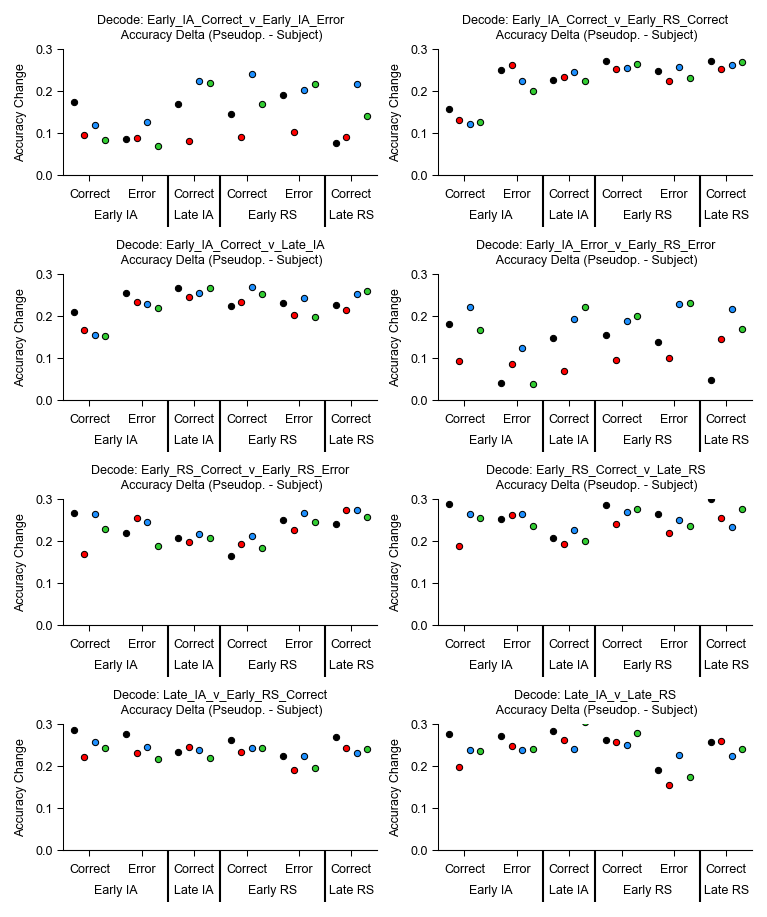

In [ ]:
figsize = (5,6)
fig_n_rows = int(np.ceil(len(comparison_list)/2))
fig_all_decode_pairs, ax_array = plt.subplots(nrows = fig_n_rows, ncols = 2, figsize = figsize, layout = 'constrained')

for comparison_count, decoder_comparison in enumerate(comparison_list):
    ax = ax_array.flat[comparison_count]
    df_curr = ppop_subj_accuracy.loc[ppop_subj_accuracy[decoding_col]== decoder_comparison,:]
    plot_params = {'data': df_curr,  'x': 'enriched_group', 'y':'ppop_minus_subj','hue': 'geno_day', 'palette':color_list, 'hue_order': geno_order}
    sc = sns.stripplot(ax = ax,**plot_params,s=3,dodge = True  )#make cosine sim plot itself
    set_ax_title_xlabel_ylabel(ax = ax, label_dict = {'title':f"Decode: {decoder_comparison}\n Accuracy Delta (Pseudop. - Subject)", 'xlabel': None, 'ylim': [0, 0.3], 'ylabel': 'Accuracy Change', 'legend_false':True})
    ax_add_stage_names_and_outline_points(ax)


#### Plot out of distribution decoding accuracy 

In [ ]:
def plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col, ax_plot):
    plot_df =  decode_out_distrib.loc[(decode_out_distrib[decoding_col] == decoder_comparison),:]
    errorbar_pi = 75
    plot_params = {'data':plot_df, 'dodge': 0.4, 'x': 'enriched_group', 'y':'accuracy','order':phase_list_IA_RS_chrono,'errorbar': ('pi', errorbar_pi), **geno_color_dict_no_errorbar}
    ## ax level changes
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params)#make cosine sim plot itself
    fig_name = f' Train: {plot_df.train_on.unique()[0]} \n Test: {plot_df.test_on.unique()[0]} \n SVM Accuracy (PI: {errorbar_pi}) ({plot_df.pseudopop_run_num.nunique()} run avg.)'
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': [0, 1.025],'xlabel': None, 'ylabel': 'Mean SVM accuracy', 'legend_false': True})#adjust plot information
    
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, test_name = 'cohen_d', detect_error_bar = False)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True, tight_offset = 0.02) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    
    ax_add_stage_names_and_outline_points(ax_plot)
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    return posthoc_df

In [ ]:
## iterate over all possible combinations
decoding_col = 'classes decoded'
comparison_list = decode_out_distrib[decoding_col].unique()
print(comparison_list)

['Early IA Correct Early RS Correct v Early IA Error Early RS Error'
 'Early IA Error Early RS Error v Early IA Correct Early RS Correct'
 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
 'Early RS Correct Early RS Error v Early IA Correct Early IA Error']


Saved 3_Decode out of distribution- Mean SVM accuracy by ensemble_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_Decode out of distribution- Mean SVM accuracy by ensemble_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_Decode out of distribution- Mean SVM accuracy by ensemble_ccgp_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_Decode out of distribution- Mean SVM accuracy by ensemble_ccgp_posthoc_results_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\_21_Jul_2025\' has been created.


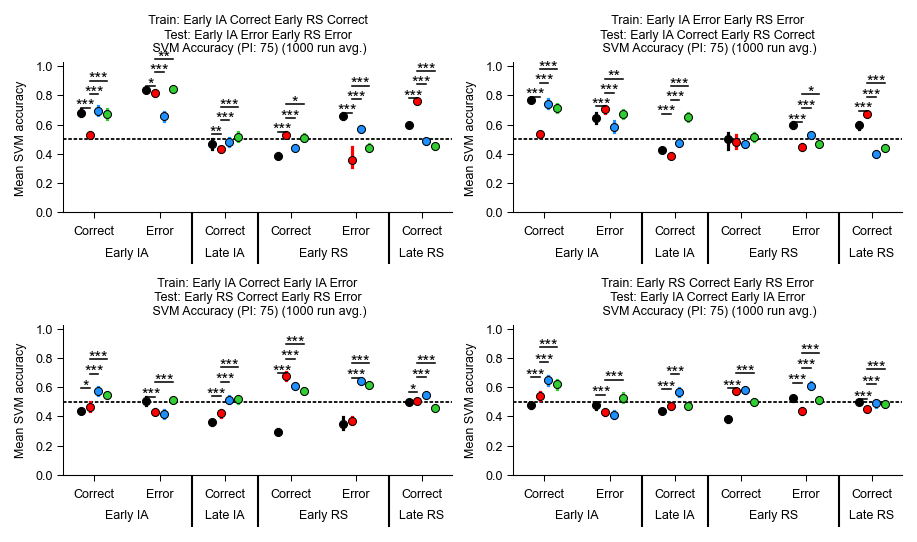

In [ ]:
figsize = (6,3.5)
n_rows = int(np.ceil(len(comparison_list)/2))
posthoc_list = []
fig_all_decode_pairs, ax_array = plt.subplots(nrows = n_rows, ncols = 2, figsize = figsize, layout = 'constrained')
for count, decoder_comparison in enumerate(comparison_list):    #set plot info ## iterate over subfigures
    posthoc_df = plot_out_of_distribution_SVM_result(decode_out_distrib, decoder_comparison, decoding_col,  ax_array.flat[count])
    posthoc_list.append(posthoc_df.assign(comparison=decoder_comparison))
##save posthoc
fig_name = f"Decode out of distribution- Mean SVM accuracy by ensemble"
posthoc_csv = pd.concat(posthoc_list) # av_cosine_sim_posthoc.loc[:, ['group_1_mean','group_1_sem','group_2_mean','group_2_sem']] = av_cosine_sim_posthoc.loc[:, ['group_1_mean','group_1_sem','group_2_mean','group_2_sem']].round(4)
#save posthoc CSV
save_plot_record_as_csv_txt(posthoc_csv,folder_pref:="3",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
#save fig
save_fig_as_filetype_list(fig_all_decode_pairs, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig_all_decode_pairs, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png', 'svg'])

In [ ]:
posthoc_csv

,category_compared_within,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_sem,group_2_mean,group_2_sem,test_name,...,g2_cat_loc,max_group_loc_val,numeric_var,hue_var,x_category_var,hue_is_x_axis,comparison,date_tag,fig_name,fig_num
0,Early_IA_Correct,WT VEH,Het VEH,"(1000,)","(1000,)",0.6818,0.0141,0.5314,0.0105,robust_cohen_d,...,-0.066667,0.682249,accuracy,geno_day,enriched_group,False,Early IA Correct Early RS Correct v Early IA E...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
1,Early_IA_Correct,Het VEH,Het CLNZ,"(1000,)","(1000,)",0.5314,0.0105,0.6958,0.0162,robust_cohen_d,...,0.066667,0.695484,accuracy,geno_day,enriched_group,False,Early IA Correct Early RS Correct v Early IA E...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
2,Early_IA_Correct,Het VEH,Het postCLNZ,"(1000,)","(1000,)",0.5314,0.0105,0.6729,0.0195,robust_cohen_d,...,0.200000,0.672666,accuracy,geno_day,enriched_group,False,Early IA Correct Early RS Correct v Early IA E...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
3,Early_IA_Error,WT VEH,Het VEH,"(1000,)","(1000,)",0.8367,0.0073,0.8163,0.0101,robust_cohen_d,...,0.933333,0.836694,accuracy,geno_day,enriched_group,False,Early IA Correct Early RS Correct v Early IA E...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
4,Early_IA_Error,Het VEH,Het CLNZ,"(1000,)","(1000,)",0.8163,0.0101,0.6563,0.0183,robust_cohen_d,...,1.066667,0.816562,accuracy,geno_day,enriched_group,False,Early IA Correct Early RS Correct v Early IA E...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,Early_RS_Error,Het VEH,Het CLNZ,"(1000,)","(1000,)",0.4360,0.0119,0.6102,0.0116,robust_cohen_d,...,4.066667,0.610227,accuracy,geno_day,enriched_group,False,Early RS Correct Early RS Error v Early IA Cor...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
14,Early_RS_Error,Het VEH,Het postCLNZ,"(1000,)","(1000,)",0.4360,0.0119,0.5123,0.0115,robust_cohen_d,...,4.200000,0.512431,accuracy,geno_day,enriched_group,False,Early RS Correct Early RS Error v Early IA Cor...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
15,Late_RS,WT VEH,Het VEH,"(1000,)","(1000,)",0.4977,0.0023,0.4520,0.0074,robust_cohen_d,...,4.933333,0.497542,accuracy,geno_day,enriched_group,False,Early RS Correct Early RS Error v Early IA Cor...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3
16,Late_RS,Het VEH,Het CLNZ,"(1000,)","(1000,)",0.4520,0.0074,0.4891,0.0123,robust_cohen_d,...,5.066667,0.489348,accuracy,geno_day,enriched_group,False,Early RS Correct Early RS Error v Early IA Cor...,21_Jul_2025,Decode out of distribution- Mean SVM accuracy ...,3


## Figure 3 & 4- Cross-condition generalization 

In [ ]:
decode_out_distrib.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 120000 entries, 0 to 11999
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   accuracy             120000 non-null  float64       
 1   num_features_used    120000 non-null  float64       
 2   num_nonzero_coef     120000 non-null  float64       
 3   true_pos             120000 non-null  float64       
 4   true_neg             120000 non-null  float64       
 5   false_pos            120000 non-null  float64       
 6   false_neg            120000 non-null  float64       
 7   pseudopop_run_num    120000 non-null  int32         
 8   enriched_group       120000 non-null  object        
 9   geno_day             120000 non-null  object        
 10  class_0_train        120000 non-null  object        
 11  class_1_train        120000 non-null  object        
 12  class_0_test         120000 non-null  object        
 13  class_1_test   

In [ ]:
confusion_mat_cols = ['true_pos','false_neg', 'false_pos', 'true_neg']
class_list = ['class_0_train','class_1_train','class_0_test','class_1_test']
run_ID_cols = ['geno_day','accuracy','pseudopop_run_num']
CCG_all_runs = decode_out_distrib.loc[:,['enriched_group']+run_ID_cols +confusion_mat_cols + class_list].rename({'enriched_group':'ensemble'},axis = 1)
CCG_all_runs

,ensemble,geno_day,accuracy,pseudopop_run_num,true_pos,false_neg,false_pos,true_neg,class_0_train,class_1_train,class_0_test,class_1_test
0,Early_IA_Correct,Het CLNZ,0.691250,0,0.417031,0.082969,0.225781,0.274219,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
1,Early_IA_Correct,Het CLNZ,0.772344,0,0.454219,0.045781,0.181875,0.318125,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct
2,Early_IA_Correct,Het CLNZ,0.569844,0,0.307500,0.192500,0.237656,0.262344,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error
3,Early_IA_Correct,Het CLNZ,0.651250,0,0.381406,0.118594,0.230156,0.269844,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error
4,Early_IA_Correct,Het VEH,0.560938,0,0.276719,0.223281,0.215781,0.284219,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...
11995,Late_RS,WT CLNZ,0.479688,999,0.298125,0.201875,0.318437,0.181563,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error
11996,Late_RS,WT VEH,0.595000,999,0.095000,0.405000,0.000000,0.500000,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
11997,Late_RS,WT VEH,0.576250,999,0.309063,0.190938,0.232812,0.267187,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct
11998,Late_RS,WT VEH,0.500000,999,0.000000,0.500000,0.000000,0.500000,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error


#### Figure 3 - CCGP Train IA Test RS

In [ ]:
#function- ax level plot of CCGP
def plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    preset_comparison_list,
    geno_color_dict_no_errorbar,  ylim:list = [0.2, 1.025], verbose_titles:list = ['train IA', 'test RS'],**kwargs
):
    """
    Plots cross-condition generalization SVM accuracy and performs post-hoc tests.

    Parameters:
    - decode_out_distrib: pd.DataFrame, decoding results
    - decoding_col: str, column name to compare with decode_comp
    - decode_comp: value to filter decoding_col on
    - enriched_group: str, column name used to group for plotting
    - ensembles_to_plot: list of group names to include in the plot
    - geno_color_dict_no_errorbar: dict, seaborn styling arguments like hue/colors
    - preset_comparison_list: list of tuples, preset comparisons for posthoc tests
    - ax_plot: matplotlib.axes.Axes, axis to plot on

    Returns:
    - ax_plot with the plot drawn and significance bars added
    """
    ## plot info 
    plot_mask = (decode_out_distrib[decoding_col] == decode_comp) & (decode_out_distrib[enriched_group].isin(ensembles_to_plot))
    plot_df =  decode_out_distrib.loc[plot_mask,:]
    plot_params = {'data':plot_df, 'dodge': 0.5,'errwidth': 1.5, 'x': 'enriched_group', 'y':'accuracy','order':ensembles_to_plot, 'errorbar': ('pi', 75), **geno_color_dict_no_errorbar}
    s = sns.pointplot(ax = ax_plot,linestyles = 'none', **plot_params,**kwargs)#make cosine sim plot itself
    ## ax level changes
    train_data, test_data = verbose_titles#new- extract cleaner string title from train/test data
    fig_name = f'{train_data.replace("_"," ")}\n{test_data.replace("_", " ")}'
    
    set_ax_title_xlabel_ylabel(ax_plot, {'title': fig_name, 'ylim': ylim, 'legend_false': False,
                                         'xlabel': f"Cell Ensemble", 'ylabel': 'Cross-condition Generalization'})#adjust plot information
    #posthoc difference detection
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, s, preset_comparison_list, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.03,offset_constant = 0.015) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax_plot.axhline(y=0.5, color="black", dashes=(2, 1), zorder=0)#add 0 second line
    set_pointplot_edgecolor(ax_plot)
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels())) # ax_plot.set_xticklabels(ax_plot.get_xticklabels(), rotation = 0, ha="center")
    ##new- add legend
    
    return posthoc_df

In [ ]:
##function for making broader plot
def make_CCGP_fig(decode_out_distrib,
                  decoding_col,
                  decode_comp,
                  enriched_group,
                  ensembles_to_plot,
                  preset_comparison_list,
                  geno_color_dict_no_errorbar,
                  ccgp_figsize = (2,2),
                  ylim:list = [0.2, 1.025],
                  verbose_dicts:dict = {},
                  legend_bbox_to_anchor = (0.55, 1.0),
                  **kwargs) -> tuple:
    ''' Creates fig/ax then calls GGCP ax-level plotting function. Then adds ax decorators as needed'''
    #make plot info 
    fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
    ##STAND ALONE FUNCTION FOR POLOTTING
    posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
                                                                 decode_out_distrib,
                                                                 decoding_col,
                                                                 decode_comp,
                                                                 enriched_group,
                                                                 ensembles_to_plot,
                                                                 preset_comparison_list,
                                                                 geno_color_dict_no_errorbar,
                                                                 ylim =ylim,   
                                                                 verbose_titles= verbose_dicts[train_data],
                                                                 scale = 1.)
    add_xtick_color_boxes(ax_plot, ensembles_to_plot, stage_palette_dict)
    ## add legend
    hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
    fig.legend(hand, labs, bbox_to_anchor=legend_bbox_to_anchor,loc = 'lower center', ncols = 4, frameon = False, title =None)
    ##save fig 
    fig_name = f"CCGP- {verbose_dicts[train_data][0]}_Early stage ens_ {date_tag}"
    print(fig_name)
    return fig, ax_plot

In [ ]:
#create longer titles for figure laouts 
train_IA_test_RS_verbose_title = ['Train on IA Trials (Classify Correct vs. Error)', 'Test on RS Trials (Classify Correct vs. Error)']
train_IA_test_RS_verbose_title_vss = ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials']
train_correct_test_error_verbose_title = ['Train on Correct Trials (Classify IA vs. RS)', 'Test on Error Trials (Classify IA vs. RS)']
train_correct_test_error_verbose_title_vss = ['Classify IA vs. RS:','Train on Correct trials, Test on Errors']
##combine into dict for substitution into figures
verbose_dicts = { 'train_Early_IA_Correct_Early_IA_Error': train_IA_test_RS_verbose_title_vss, 
                 'train_Early_IA_Correct_Early_RS_Correct':train_correct_test_error_verbose_title_vss}
print(verbose_dicts)
train_data = 'train_Early_IA_Correct_Early_IA_Error'
test_data = 'test_Early_RS_Correct_Early_RS_Error'

{'train_Early_IA_Correct_Early_IA_Error': ['Classify Correct vs. Error:', 'Train on IA trials, Test on RS trials'], 'train_Early_IA_Correct_Early_RS_Correct': ['Classify IA vs. RS:', 'Train on Correct trials, Test on Errors']}


CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jul_2025
Saved 3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jul_2025_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jul_2025_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jul_2025_ccgp_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_CCGP- Train on IA trials, Test on RS trials_Early stage ens_ 21_Jul_2025_ccgp_posthoc_results_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\' already exists.
The folder '\My Drive\Colab 

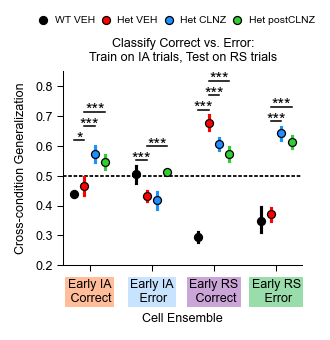

In [ ]:
## iterate over all possible combinations
decoding_col = 'classes decoded'
enriched_group = 'enriched_group'
comparison_list = decode_out_distrib[decoding_col].unique()
decode_comp = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']
train_data = 'train_Early_IA_Correct_Early_IA_Error'
##make plot info 
ccgp_figsize = (2,2)
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
##STAND ALONE FUNCTION FOR POLOTTING
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
                                                             decode_out_distrib,
                                                             decoding_col,
                                                             decode_comp,
                                                             enriched_group,
                                                             ensembles_to_plot,
                                                             preset_comparison_list,
                                                             geno_color_dict_no_errorbar,
                                                             ylim =[0.2, 0.85],   
                                                             verbose_titles= verbose_dicts[train_data],
                                                             scale = 1.)
add_xtick_color_boxes(ax_plot, ensembles_to_plot, stage_palette_dict)
## add legend
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None)
##save fig 
fig_name = f"CCGP- {verbose_dicts[train_data][1]}_Early stage ens_ {date_tag}"
print(fig_name)
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="3",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
##save fig
save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=3, filetypes_to_save = ['pdf', 'png','svg'])

#### Figure 4 - CCGP Early IA/RS Correct

Saved 4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_SVM generalize (early ens) train_correct_test_error accuracy_ccgp_posthoc_results_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\_21_Jul_2025\' has been created.


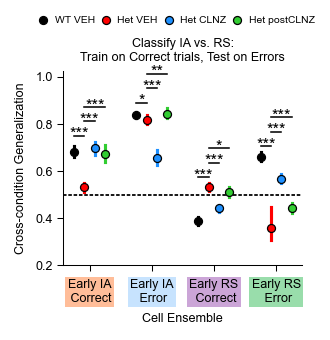

In [ ]:
## iterate over all possible combinations
decoding_col = 'classes decoded'
enriched_group = 'enriched_group'
comparison_list = decode_out_distrib[decoding_col].unique()
decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error',]
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
test_data = 'test_Early_IA_Error_Early_RS_Error'
##STAND ALONE FUNCTION FOR POLOTTING
posthoc_df = plot_cross_condition_generalization_performance(ax_plot,
    decode_out_distrib,decoding_col,decode_comp,
    enriched_group,ensembles_to_plot,
    preset_comparison_list,geno_color_dict_no_errorbar,  verbose_titles= verbose_dicts[train_data],scale = 1.)
add_xtick_color_boxes(ax_plot, ensembles_to_plot, stage_palette_dict)
## add legend
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )

##save fig_posthoc 
fig_name = f"SVM generalize (early ens) train_correct_test_error accuracy"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="ccgp_all_posthoc cohen d",txt_suffix="ccgp_posthoc_results_text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=4, filetypes_to_save = ['pdf', 'png','svg'])

#### supplement- CCGP with WT-CLNZ included

Saved 4_s_SVM generalize supp (+WT CLNZ) train_correct_test_error accuracy_supp_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_s_SVM generalize supp (+WT CLNZ) train_correct_test_error accuracy_supp_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_s_SVM generalize supp (+WT CLNZ) train_correct_test_error accuracy_supp_ccgp_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_s_SVM generalize supp (+WT CLNZ) train_correct_test_error accuracy_supp_ccgp_posthoc_results_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\_21_Jul_2025\' already e

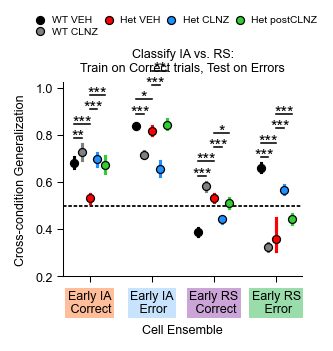

In [ ]:
## iterate over all possible combinations
enriched_group = 'enriched_group'
comparison_list = decode_out_distrib[decoding_col].unique()
decode_comp = 'Early IA Correct Early RS Correct v Early IA Error Early RS Error'
## figure params 
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')
ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error',]
train_data = 'train_Early_IA_Correct_Early_RS_Correct'
test_data = 'test_Early_IA_Error_Early_RS_Error'
##STAND ALONE FUNCTION FOR POLOTTING
posthoc_df = plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    comparison_list_w_WT_CLNZ,
    format_no_eb_w_WT_CLNZ,
    verbose_titles= verbose_dicts[train_data],
    scale = 1.)
add_xtick_color_boxes(ax_plot, ensembles_to_plot, stage_palette_dict)
## add legend
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )

##save fig_posthoc 
fig_name = f"SVM generalize supp (+WT CLNZ) train_correct_test_error accuracy"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="4_s",fig_name,
                            csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="supp_ccgp_all_posthoc cohen d",txt_suffix="supp_ccgp_posthoc_results_text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_4', filetypes_to_save = ['pdf', 'png','svg'])

In [ ]:
3.5/4

0.875

Saved 3_s_SVM generalize supp (+WT CLNZ) train_IA_test_RS accuracy_supp_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_s_SVM generalize supp (+WT CLNZ) train_IA_test_RS accuracy_supp_ccgp_all_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_s_SVM generalize supp (+WT CLNZ) train_IA_test_RS accuracy_supp_ccgp_posthoc_results_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_s_SVM generalize supp (+WT CLNZ) train_IA_test_RS accuracy_supp_ccgp_posthoc_results_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_3\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_3\_21_Jul_2025\' already exists.


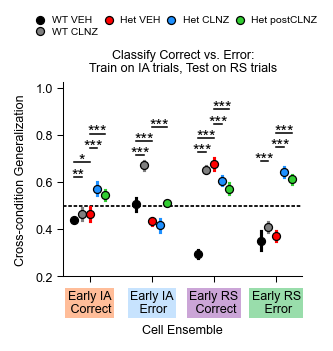

In [ ]:
decoding_col = 'classes decoded'
enriched_group = 'enriched_group'
comparison_list = decode_out_distrib[decoding_col].unique()
decode_comp = 'Early IA Correct Early IA Error v Early RS Correct Early RS Error'
##make plot info 
ccgp_figsize = (2,2)
fig, ax_plot = plt.subplots(1,1, figsize = ccgp_figsize, layout = 'constrained')

ensembles_to_plot = ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error']
## func
train_data = 'train_Early_IA_Correct_Early_IA_Error'
##STAND ALONE FUNCTION FOR POLOTTING
posthoc_df = plot_cross_condition_generalization_performance(
    ax_plot,
    decode_out_distrib,
    decoding_col,
    decode_comp,
    enriched_group,
    ensembles_to_plot,
    comparison_list_w_WT_CLNZ,
    format_no_eb_w_WT_CLNZ,
    verbose_titles= verbose_dicts[train_data],
    scale = 1.)
add_xtick_color_boxes(ax_plot, ensembles_to_plot, stage_palette_dict)
## add legend
hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.55, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )

##save fig_posthoc 
fig_name = f"SVM generalize supp (+WT CLNZ) train_IA_test_RS accuracy"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="3_s",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="supp_ccgp_all_posthoc cohen d",txt_suffix="supp_ccgp_posthoc_results_text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='s_3', filetypes_to_save = ['pdf', 'png','svg'])

In [ ]:
 #create custom replacement for each test class for legend, depending on type of CCGP
custom_legend_labels = {'test_Early_IA_Error_Early_RS_Error': {'Early_IA_Correct': "Decoded as IA",'Early_RS_Correct': "Decoded as RS"},
                       'test_Early_RS_Correct_Early_RS_Error': {'Early_IA_Correct': "Decoded as Correct",'Early_IA_Error': "Decoded as Error"},}


## Plot Confusion CCG Distributions

In [ ]:
CCG_all_runs

,ensemble,geno_day,accuracy,pseudopop_run_num,true_pos,false_neg,false_pos,true_neg,class_0_train,class_1_train,class_0_test,class_1_test
0,Early_IA_Correct,Het CLNZ,0.691250,0,0.417031,0.082969,0.225781,0.274219,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
1,Early_IA_Correct,Het CLNZ,0.772344,0,0.454219,0.045781,0.181875,0.318125,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct
2,Early_IA_Correct,Het CLNZ,0.569844,0,0.307500,0.192500,0.237656,0.262344,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error
3,Early_IA_Correct,Het CLNZ,0.651250,0,0.381406,0.118594,0.230156,0.269844,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error
4,Early_IA_Correct,Het VEH,0.560938,0,0.276719,0.223281,0.215781,0.284219,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...
11995,Late_RS,WT CLNZ,0.479688,999,0.298125,0.201875,0.318437,0.181563,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error
11996,Late_RS,WT VEH,0.595000,999,0.095000,0.405000,0.000000,0.500000,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error
11997,Late_RS,WT VEH,0.576250,999,0.309063,0.190938,0.232812,0.267187,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct
11998,Late_RS,WT VEH,0.500000,999,0.000000,0.500000,0.000000,0.500000,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error


In [ ]:
df = CCG_all_runs
# 2. Make sure your class columns are strings'
df[class_list] = df[class_list].astype(str)

# 3. Build all your new columns in one go via vectorized string operations
df = df.assign(
    train_on = 'train_' + df['class_0_train'] + '_x_' + df['class_1_train'],
    test_on  = 'test_'  + df['class_0_test']  + '_x_' + df['class_1_test'],
    Predict_class_1_train_x_Actual_class_1_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_0_train_x_Actual_class_1_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_1_test']),
    Predict_class_1_train_x_Actual_class_0_test = ('Predict_' + df['class_1_train'] + '_x_Actual_' + df['class_0_test']),
    Predict_class_0_train_x_Actual_class_0_test = ('Predict_' + df['class_0_train'] + '_x_Actual_' + df['class_0_test'])
)
confusion_names = ['Predict_class_1_train_x_Actual_class_1_test',
                   'Predict_class_0_train_x_Actual_class_1_test',
                   'Predict_class_1_train_x_Actual_class_0_test', 
                   'Predict_class_0_train_x_Actual_class_0_test']

grouped = df[['ensemble', 'train_on','test_on'] +confusion_mat_cols + run_ID_cols+ confusion_names].set_index(['train_on', 'test_on','ensemble'])
grouped

,,,true_pos,false_neg,false_pos,true_neg,geno_day,accuracy,pseudopop_run_num,Predict_class_1_train_x_Actual_class_1_test,Predict_class_0_train_x_Actual_class_1_test,Predict_class_1_train_x_Actual_class_0_test,Predict_class_0_train_x_Actual_class_0_test
train_on,test_on,ensemble,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,0.417031,0.082969,0.225781,0.274219,Het CLNZ,0.691250,0,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,0.454219,0.045781,0.181875,0.318125,Het CLNZ,0.772344,0,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error_x_Actual_Early_IA_Correct
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,0.307500,0.192500,0.237656,0.262344,Het CLNZ,0.569844,0,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Correct_x_Actual_Early_RS_Cor...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,0.381406,0.118594,0.230156,0.269844,Het CLNZ,0.651250,0,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,0.276719,0.223281,0.215781,0.284219,Het VEH,0.560938,0,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,0.298125,0.201875,0.318437,0.181563,WT CLNZ,0.479688,999,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,0.095000,0.405000,0.000000,0.500000,WT VEH,0.595000,999,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,0.309063,0.190938,0.232812,0.267187,WT VEH,0.576250,999,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error_x_Actual_Early_IA_Correct


In [ ]:
long_grouped_confusion = grouped.reset_index().melt(
    id_vars = ['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy', 'pseudopop_run_num'] + confusion_names,
                          value_vars = ['true_pos', 'false_neg', 'false_pos', 'true_neg'])
# 1. Define the mapping from your “variable” names to the Predict_… columns
df= long_grouped_confusion
col_map = {
    'true_pos':  'Predict_class_1_train_x_Actual_class_1_test',
    'false_neg': 'Predict_class_0_train_x_Actual_class_1_test',
    'false_pos': 'Predict_class_1_train_x_Actual_class_0_test',
    'true_neg':  'Predict_class_0_train_x_Actual_class_0_test',
}
df['var_column'] = df['variable'].map(col_map) #name of column containing var info
df['labels'] = df.apply(lambda row: row[row['var_column']],axis=1)
df[['predict', 'actual']] = df.labels.str.split("_x_", expand = True)
df

,train_on,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,Predict_class_1_train_x_Actual_class_1_test,Predict_class_0_train_x_Actual_class_1_test,Predict_class_1_train_x_Actual_class_0_test,Predict_class_0_train_x_Actual_class_0_test,variable,value,var_column,labels,predict,actual
0,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.691250,0,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,true_pos,0.417031,Predict_class_1_train_x_Actual_class_1_test,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Actual_Early_RS_Error
1,train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.772344,0,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,true_pos,0.454219,Predict_class_1_train_x_Actual_class_1_test,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Actual_Early_RS_Correct
2,train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.569844,0,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Correct_x_Actual_Early_RS_Cor...,true_pos,0.307500,Predict_class_1_train_x_Actual_class_1_test,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Actual_Early_RS_Error
3,train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.651250,0,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,true_pos,0.381406,Predict_class_1_train_x_Actual_class_1_test,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Actual_Early_IA_Error
4,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.560938,0,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,true_pos,0.276719,Predict_class_1_train_x_Actual_class_1_test,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Actual_Early_RS_Error
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479995,train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.479688,999,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,true_neg,0.181563,Predict_class_0_train_x_Actual_class_0_test,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Actual_Early_IA_Correct
479996,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.595000,999,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_IA_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,true_neg,0.500000,Predict_class_0_train_x_Actual_class_0_test,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Actual_Early_IA_Error
479997,train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.576250,999,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_IA_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,true_neg,0.267187,Predict_class_0_train_x_Actua

In [ ]:
ccg_confusion_long = df[['train_on', 'test_on', 'ensemble', 'geno_day', 'accuracy','pseudopop_run_num','value','labels', 'predict', 'actual', 'var_column', 'variable']]
ccg_confusion_long

,train_on,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
0,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.691250,0,0.417031,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Actual_Early_RS_Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
1,train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.772344,0,0.454219,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Actual_Early_RS_Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
2,train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.569844,0,0.307500,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Actual_Early_RS_Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
3,train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.651250,0,0.381406,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Actual_Early_IA_Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
4,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.560938,0,0.276719,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Actual_Early_RS_Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...,...
479995,train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.479688,999,0.181563,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Actual_Early_IA_Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
479996,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.595000,999,0.500000,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Actual_Early_IA_Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
479997,train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.576250,999,0.267187,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Actual_Early_IA_Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
479998,train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Late_RS,WT VEH,0.500000,999,0.500000,Predict_Early_IA_Correct_x_Actual_Early_RS_Cor...,Predict_Early_IA_Correct,Actual_Early_RS_Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


In [ ]:
### new, WIP to understand why difference exists in difff versus raw
predictions = ccg_confusion_long.groupby(by = ['train_on','test_on'])['predict'].apply(lambda x: sorted(x.unique())).reset_index() #make index of sorted unique vals
predictions

,train_on,test_on,predict
0,train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,"[Predict_Early_IA_Correct, Predict_Early_IA_Er..."
1,train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,"[Predict_Early_IA_Correct, Predict_Early_RS_Co..."
2,train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,"[Predict_Early_IA_Error, Predict_Early_RS_Error]"
3,train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,"[Predict_Early_RS_Correct, Predict_Early_RS_Er..."


In [ ]:
confusion_col_names = {'train_Early_IA_Correct_Early_IA_Error': ["Predict Correct - Predict Error", ['Predict_Early_IA_Correct', 'Predict_Early_IA_Error']], 
                       'train_Early_IA_Correct_Early_RS_Correct': ["Predict IA - Predict RS", ['Predict_Early_IA_Correct', 'Predict_Early_RS_Correct']]}

In [ ]:
confusion_col_names

{'train_Early_IA_Correct_Early_IA_Error': ['Predict Correct - Predict Error',
  ['Predict_Early_IA_Correct', 'Predict_Early_IA_Error']],
 'train_Early_IA_Correct_Early_RS_Correct': ['Predict IA - Predict RS',
  ['Predict_Early_IA_Correct', 'Predict_Early_RS_Correct']]}

In [ ]:
ccg_confusion_figsize = (1.65,2)

In [ ]:
'''To try out plotting boht numbers ''' 
input_df = ccg_confusion_long.set_index(("train_on")).copy()
input_df.loc[:,'actual'] = input_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace("_"," ")
input_df['value'] = input_df['value']*2
input_df

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.691250,0,0.834062,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Early_IA_Correct,Het CLNZ,0.772344,0,0.908438,Predict_Early_RS_Error_x_Actual_Early_RS_Correct,Predict_Early_RS_Error,Early RS Correct,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_IA_Error,test_Early_RS_Correct_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.569844,0,0.615000,Predict_Early_IA_Error_x_Actual_Early_RS_Error,Predict_Early_IA_Error,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Early_IA_Correct,Het CLNZ,0.651250,0,0.762813,Predict_Early_RS_Error_x_Actual_Early_IA_Error,Predict_Early_RS_Error,Early IA Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.560938,0,0.553438,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...
train_Early_RS_Correct_x_Early_RS_Error,test_Early_IA_Correct_x_Early_IA_Error,Late_RS,WT CLNZ,0.479688,999,0.363125,Predict_Early_RS_Correct_x_Actual_Early_IA_Cor...,Predict_Early_RS_Correct,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Late_RS,WT VEH,0.595000,999,1.000000,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Error_x_Early_RS_Error,test_Early_IA_Correct_x_Early_RS_Correct,Late_RS,WT VEH,0.576250,999,0.534375,Predict_Early_IA_Error_x_Actual_Early_IA_Correct,Predict_Early_IA_Error,Early IA Correct,Predict_class_0_train_x_Actual_class_0_test,true_neg


#### plot single proportion 

In [ ]:
def plot_ccg_confusion_single_proportion(ax,
                                         input_df,
                                         train,
                                         ens,
                                         prediction_class = "Predict_Early_RS_Correct",
                                         genos_to_plot = geno_order,
                                         errorbar = ('pi', 95),
                                         ylim=[0, 0.515],
                                         title_type = {'train_Early_IA_Correct_x_Early_RS_Correct':'Classification (IA vs. RS) of',
                                                       'train_Early_IA_Correct_x_Early_IA_Error': 'Classification (correct vs. error) of'},
                                         **kwargs):
    ''' started 6/25/25- To plot distributions of ccg''' 
    
    #modify df for better plot
    train_df = input_df.loc[train,:].reset_index()
    plot_df = train_df.loc[train_df.ensemble == ens,:].copy()
    
    plot_df.loc[:,'actual'] = plot_df.loc[:,'actual'].str.removeprefix("Actual_").str.replace("_"," ")
    
    #given you plot only one type, filter by type
    plot_df = plot_df.loc[plot_df.predict == prediction_class,:]
    plot_df['value'] = plot_df['value'] *100 #multiply by 100 to return percent
    # plot data
    stage_order = sorted(set(plot_df.loc[:,'actual']))
    plot_params = dict(data = plot_df,ax = ax,
                       x = 'actual', y = 'value', 
                       dodge = 0.5, linestyles = 'none',
                       order = stage_order,errorbar = errorbar, 
                       **{True:geno_order_w_WT_CLNZ_no_eb, False:geno_color_dict_no_errorbar}["WT CLNZ" in genos_to_plot])
    s = sns.pointplot(**plot_params)
    ###modify ax decorators
    set_pointplot_edgecolor(ax)
    ax_title = f"{title_type[train]}\n activity in {ens.replace("_", " ")} ensemble"
    #old label
    # prediction_label = prediction_to_plot.replace("Predict", "% Classified as").replace("_", " ").replace("Early ", "")
    #new label:
    ylabel_options = {'train_Early_IA_Correct_x_Early_IA_Error': 'Correct',
                      'train_Early_IA_Correct_x_Early_RS_Correct':'RS'}
    prediction_label =  f"% Classified as {ylabel_options[train]}"
    set_labels(ax, label_dict = {'title':ax_title,
                                 'legend_false':True, 
                                 'xlabel':f"Test Data Stage",
                                 'ylim':ylim,
                                'ylabel': prediction_label})
    #run posthoc test 
    if "WT CLNZ" in plot_params['hue_order']: #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
        
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, s, comparisons, detect_error_bar = True,test_name = 'cohen_d')
    plot_sig_bars_w_comp_df_tight(ax, posthoc_df[posthoc_df['pvalue'] < 0.05], tight_offset = 0.0175,offset_constant = 0.0085) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    #more ax tuning
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels())) # ax_plot.set_xticklabels(ax_plot.get_xticklabels(), rotation = 0, ha="center")
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 100])
    return posthoc_df

In [ ]:
ccg_uniprop_figsize = (1.5, 2)

Saved 3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\_21_Jul_2025\' already exists.


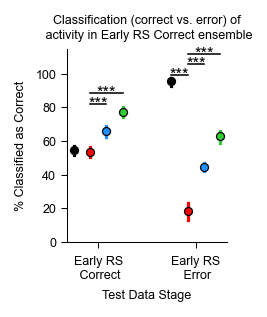

In [ ]:
##Figure 3- TRAIN IA
train = 'train_Early_IA_Correct_x_Early_IA_Error'
ensemble = "Early_RS_Correct"
genos_to_plot = geno_order #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_IA_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = train,
                                                  ens= ensemble,
                                                  genos_to_plot = genos_to_plot,
                                                  prediction_class=prediction_to_plot,
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 115],)

##savefig 
fig_num = 3
fig_name = f"CCG single class pred- Train IA test RS - {ensemble} ensemble"
prefix = ""
save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix=prefix + "predict_posthoc cohen d",txt_suffix= prefix + "predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

Saved 4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\_21_Jul_2025\' already exi

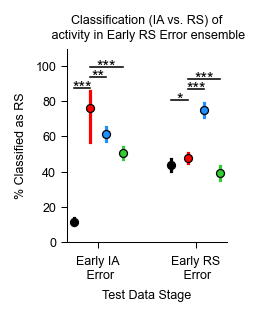

In [ ]:
##FIGURE 4- Train COrrect
train = 'train_Early_IA_Correct_x_Early_RS_Correct'
ensemble = "Early_RS_Error"
genos_to_plot = geno_order #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_RS_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax,
                                                  input_df,
                                                  train = train,
                                                  ens= ensemble,
                                                  genos_to_plot = genos_to_plot,
                                                  prediction_class=prediction_to_plot,
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)

##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
prefix = ""
save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix=prefix + "predict_posthoc cohen d",txt_suffix= prefix + "predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

In [ ]:
train_4c  = 'train_Early_IA_Correct_x_Early_RS_Correct'
ensemble_4c = "Early_IA_Correct"
fig_4_data = input_df.loc[train_4c,:]
mask_4c = (fig_4_data.ensemble == ensemble_4c) 
data_4c = fig_4_data.loc[mask_4c,:]
data_4c

,test_on,ensemble,geno_day,accuracy,pseudopop_run_num,value,labels,predict,actual,var_column,variable
train_on,,,,,,,,,,,
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.691250,0,0.834062,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.560938,0,0.553438,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het postCLNZ,0.654062,0,0.914687,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,WT CLNZ,0.747500,0,0.726875,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,WT VEH,0.673594,0,0.890000,Predict_Early_RS_Correct_x_Actual_Early_RS_Error,Predict_Early_RS_Correct,Early RS Error,Predict_class_1_train_x_Actual_class_1_test,true_pos
...,...,...,...,...,...,...,...,...,...,...,...
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het CLNZ,0.687969,999,0.513125,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het VEH,0.524062,999,0.557813,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg
train_Early_IA_Correct_x_Early_RS_Correct,test_Early_IA_Error_x_Early_RS_Error,Early_IA_Correct,Het postCLNZ,0.740938,999,0.596250,Predict_Early_IA_Correct_x_Actual_Early_IA_Error,Predict_Early_IA_Correct,Early IA Error,Predict_class_0_train_x_Actual_class_0_test,true_neg


Saved 4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_4\_21_Jul_2025\' alr

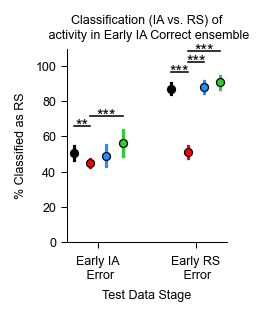

In [ ]:
#to do this, you need to set a pre-determined prediction to plot 

#figure 3- Early RS Correc ensemble- predicting Error
# figure 4- Early IA Correct ensemble- predicting IA
# figure 4- Early RS Error ensemble- predicting RS 
train = 'train_Early_IA_Correct_x_Early_RS_Correct'
ensemble = "Early_IA_Correct"
genos_to_plot = geno_order #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_RS_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = train,
                                       ens= ensemble,
                                       genos_to_plot = genos_to_plot,
                                                  prediction_class=prediction_to_plot,
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 110],)
##savefig 
fig_num = 4
fig_name = f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
prefix = ""
save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix=prefix + "predict_posthoc cohen d",txt_suffix= prefix + "predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=fig_num, filetypes_to_save = ['png','svg'])

In [ ]:
posthoc_df

,category_compared_within,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_1_sem,group_2_mean,group_2_sem,test_name,...,g_2_child_x,g_2_child_y,max_group_loc_val,numeric_var,hue_var,x_category_var,hue_is_x_axis,date_tag,fig_name,fig_num
0,Early RS Error,WT VEH,Het VEH,"(1000,)","(1000,)",86.5991,1.4655,51.3530,1.8012,robust_cohen_d,...,"[0.92, 0.92]","[47.90234375, 54.53125]",90.132813,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4
1,Early RS Error,Het VEH,Het CLNZ,"(1000,)","(1000,)",51.3530,1.8012,88.1922,1.9148,robust_cohen_d,...,"[1.08, 1.08]","[84.55859375, 91.37890625]",91.378906,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4
2,Early RS Error,Het VEH,Het postCLNZ,"(1000,)","(1000,)",51.3530,1.8012,91.2013,1.9930,robust_cohen_d,...,"[1.25, 1.25]","[87.05859375000001, 94.56640625]",94.566406,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4
3,Early IA Error,WT VEH,Het VEH,"(1000,)","(1000,)",50.4106,2.2366,45.0401,1.2362,robust_cohen_d,...,"[-0.08, -0.08]","[42.78125000000001, 47.2265625]",54.656250,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4
4,Early IA Error,Het VEH,Het CLNZ,"(1000,)","(1000,)",45.0401,1.2362,48.9692,3.2132,robust_cohen_d,...,"[0.08, 0.08]","[43.46875, 54.94140625000001]",54.941406,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4
5,Early IA Error,Het VEH,Het postCLNZ,"(1000,)","(1000,)",45.0401,1.2362,56.4174,4.1895,robust_cohen_d,...,"[0.25, 0.25]","[48.68359375, 63.91015625]",63.910156,value,geno_day,actual,False,21_Jul_2025,CCG single class pred- Train Correct test Erro...,4


#### supplement uniproportion CCG classes

switching posthoc comparison to include WT CLNZ
Saved 3_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_s_supp_CCG single class pred- Train IA test RS - Early_RS_Correct ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_3\' already exists.
The folder '\My 

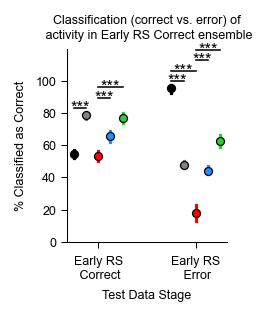

In [ ]:
## SUPP Figure 3- TRAIN IA
train = 'train_Early_IA_Correct_x_Early_IA_Error'
ensemble = "Early_RS_Correct"
genos_to_plot = geno_order_w_WT_CLNZ #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_IA_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = train,
                                       ens= ensemble,
                                       genos_to_plot = genos_to_plot,
                                                  prediction_class=prediction_to_plot,
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 120],)

##savefig 
fig_num = 3
prefix = f"supp_"
fig_name = prefix + f"CCG single class pred- Train IA test RS - {ensemble} ensemble"

save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}_s",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix=prefix + "predict_posthoc cohen d",txt_suffix= prefix + "predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_{fig_num}", filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 4_s_supp_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_s_supp_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_s_supp_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_s_supp_CCG single class pred- Train Correct test Error- Early_RS_Error ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\' already exis

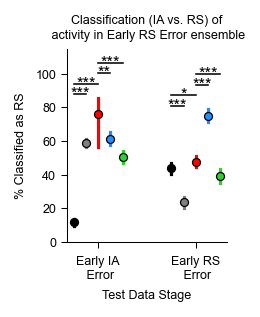

In [ ]:
#SUPP FIGURE 4

#figure 3- Early RS Correc ensemble- predicting Error
# figure 4- Early IA Correct ensemble- predicting IA
# figure 4- Early RS Error ensemble- predicting RS 
train = 'train_Early_IA_Correct_x_Early_RS_Correct'
ensemble = "Early_RS_Error"
genos_to_plot = geno_order_w_WT_CLNZ #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_RS_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                                  train = train,
                                                  ens= ensemble,
                                                  genos_to_plot = genos_to_plot,
                                                  prediction_class=prediction_to_plot,
                                                  errorbar = ('pi', 75),
                                                  ylim=[0, 115],)

##savefig 
fig_num = 4
prefix = f"supp_"
fig_name = prefix + f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}_s",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_{fig_num}', filetypes_to_save = ['png','svg'])

switching posthoc comparison to include WT CLNZ
Saved 4_s_supp_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 4_s_supp_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_supp_predict_posthoc cohen d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/4_s_supp_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/4_s_supp_CCG single class pred- Train Correct test Error- Early_IA_Correct ensemble_supp_predict_posthoc cohen d text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_4\' alre

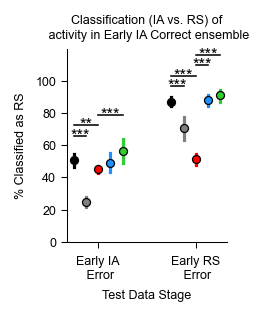

In [ ]:
#FIGURE 4- IA Correct

#figure 3- Early RS Correc ensemble- predicting Error
# figure 4- Early IA Correct ensemble- predicting IA
# figure 4- Early RS Error ensemble- predicting RS 
train = 'train_Early_IA_Correct_x_Early_RS_Correct'
ensemble = "Early_IA_Correct"
genos_to_plot = geno_order_w_WT_CLNZ #specify if including WT CLNZ

prediction_to_plot = "Predict_Early_RS_Correct"
# genos_to_plot = geno_order
fig, ax = plt.subplots(1,1, figsize = ccg_uniprop_figsize, layout = 'constrained')
posthoc_df = plot_ccg_confusion_single_proportion(ax, input_df,
                                       train = train,
                                       ens= ensemble,
                                       genos_to_plot = genos_to_plot,
                                       errorbar = ('pi', 75),
                                       ylim=[0, 120],)
##savefig 
fig_num = 4
prefix = f"supp_"
fig_name = prefix +  f"CCG single class pred- Train Correct test Error- {ensemble} ensemble"
save_plot_record_as_csv_txt(posthoc_df,folder_pref := f"{fig_num}_s",fig_name, csv_folder_most_recent, csv_folder_current_run,
                        csv_suffix="supp_predict_posthoc cohen d",txt_suffix="supp_predict_posthoc cohen d text")
save_fig_as_filetype_list(fig, fig_name , subfolder_names, ['png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f's_{fig_num}', filetypes_to_save = ['png','svg'])

## Plotting figures- specific comparisons of interest 

### Define SVM accuracy subset plotting 

In [ ]:
from matplotlib import ticker
def plot_decode_accuracy_ensemble_subset(pop_mean_decoding,
                                         decoding_col, 
                                         decoder_comparison, 
                                         ensemble_col,
                                         ax_plot,
                                         ensemble_subset=None, 
                                         ylim = None,
                                         verbose_title = True,
                                         plot_config = geno_color_dict_no_errorbar,
                                        **kwargs):
    ''' TO- plot 1 panel of SVM accuracy for 1 class decoding comparison, 
    for all ensemble groups ued for decoding.
    inputs:
    plot config- usually contains geno_color_dict/ describes default paleete info, etc ''' 
    if ensemble_subset == None:
        ensemble_subset= pop_mean_decoding[ensemble_col].unique()
    if ylim == None:
        ylim = [0.8, 1.05]
    #main
    ensemble_order = [x for x in phase_list_IA_RS_chrono if x in ensemble_subset ]
    plot_df =  pop_mean_decoding.loc[(pop_mean_decoding[decoding_col] == decoder_comparison)&(pop_mean_decoding[ensemble_col].isin(ensemble_subset)) ,:]
    
    plot_params = {'data':plot_df, 'dodge': 0.35, 'markers': 'o','orient':'v',
                   'x': 'enriched_group', 'y':'accuracy', 
                   'order':ensemble_order, 'errorbar': ('pi', 75), 'errwidth': 1.25, **plot_config}
    sc = sns.pointplot(ax = ax_plot, linestyles = 'none', **plot_params)#make cosine sim plot itself
    ## ax level changes
    if verbose_title:
        verbose_decode = verbose_titles[decoder_comparison].replace("as", "as:\n")
        ax_title = f'Classify {verbose_decode}'
    else:
        ax_title = f'{decoder_comparison}:\n Decoding by ensemble' 
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)
    ##posthoc
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title.replace("_"," "),
                                         'ylim': ylim,
                                         'xlabel': "Cell Ensemble",
                                         'ylabel': 'Mean accuracy',
                                         'legend_false':False})#adjust plot information
    #NEW- alternate what comparison list to use based on if WT-CLNZ in hue_order or not
    if "WT CLNZ" in plot_params['hue_order']:
        print(f"switching posthoc comparison to include WT CLNZ")
        comparisons = comparison_list_w_WT_CLNZ
    else:
        comparisons = preset_comparison_list
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, comparisons,
                                                           test_name = 'cohen_d',detect_error_bar=True)
    plot_sig_bars_w_comp_df_tight(ax_plot, posthoc_df[posthoc_df['pvalue'] < 0.05], tight = True,tight_offset = 0.04,offset_constant = 0.01) #default_star_bbox_size = 0.045 #in ax fraction, determined empirically
    # print(ensemble_subset)
    ##format ax 
    ax_plot.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax_plot.get_xticklabels()))
    add_xtick_color_boxes(ax_plot, ensemble_subset, stage_palette_dict)
    return posthoc_df

In [ ]:

def plot_save_ensemble_svm_accuracy(decoding_df,
                                    decoder_comparison:str,
                                    ensemble_subset:list= [],
                                    decoding_col:str = 'classes decoded', 
                                    figsize =(1.65,2), 
                                    fig_layout = 'tight',
                                    bbox_to_anchor=(0.7, .975),
                                    ylim = [0.90,1.015],
                                    fig_name = f"{decoder_comparison} SVM accuracy by ensem",
                                    fig_folder=5,
                                    add_legend = False,
                                    **kwargs):
        
    fig, ax = plt.subplots(1,1, figsize =figsize, layout = fig_layout)
    posthoc_df = plot_decode_accuracy_ensemble_subset(decoding_df, decoding_col, 
                                                      decoder_comparison, 'enriched_group',
                                                      ax,
                                                      ensemble_subset= ensemble_subset,ylim = ylim,
                                                      **kwargs)
    #fix,tune axes
    current_ticks = ax.get_yticks()
    ax.set_yticks(current_ticks[current_ticks <= 1.0])
    ## add legend
    if add_legend:
        hand, labs =ax.get_legend_handles_labels() #pull legend from final PCA object and delete it
        fig.legend(hand, labs, bbox_to_anchor=(0.55, .975),loc = 'lower center', ncols = 4, frameon = False, title =None, **{
            'labelspacing': 0.0,
            'markerscale': 1,
            'borderpad': 0.0,
            'columnspacing': 0.0,
            'handletextpad': 0.0})
    #save figs 
    fig_name = f"{decoder_comparison} SVM accuracy by ensem"
    save_fig_as_filetype_list(fig,  fig_name, subfolder_names, [ 'svg', 'pdf', 'png'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, 
                             folder_key=fig_folder, 
                             filetypes_to_save = ['png', 'svg','pdf'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = fig_name
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_folder}",
                                fig_name,
                                csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="posthoc decode acc cohen D",txt_suffix="posthoc_text")
    
    return fig, ax,posthoc_df 

### Figure 3- plot decoding acc: Early RS correct v Early RS Error for: Early RS correct and early RS error ensembles
 Hypothesis: error signals are inappropriately weak / not sufficiently different from correct trials

In [ ]:
pop_mean_decoding

,geno_day,enriched_group,classes decoded,pseudopop_run_num,accuracy,class_0,class_1
0,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,0,0.99375,Early_IA_Correct,Early_IA_Error
1,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,1,0.99250,Early_IA_Correct,Early_IA_Error
2,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,2,0.99375,Early_IA_Correct,Early_IA_Error
3,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,3,0.99375,Early_IA_Correct,Early_IA_Error
4,Het CLNZ,Early_IA_Correct,Early_IA_Correct_v_Early_IA_Error,4,0.98250,Early_IA_Correct,Early_IA_Error
...,...,...,...,...,...,...,...
239995,WT VEH,Late_RS,Late_IA_v_Late_RS,995,0.87875,Late_IA,Late_RS
239996,WT VEH,Late_RS,Late_IA_v_Late_RS,996,0.87250,Late_IA,Late_RS
239997,WT VEH,Late_RS,Late_IA_v_Late_RS,997,0.88000,Late_IA,Late_RS
239998,WT VEH,Late_RS,Late_IA_v_Late_RS,998,0.85625,Late_IA,Late_RS


In [ ]:
decoded_pairs = pop_mean_decoding['classes decoded'].unique().tolist()
decoded_pairs

['Early_IA_Correct_v_Early_IA_Error',
 'Early_IA_Correct_v_Early_RS_Correct',
 'Early_IA_Correct_v_Late_IA',
 'Early_IA_Error_v_Early_RS_Error',
 'Early_RS_Correct_v_Early_RS_Error',
 'Early_RS_Correct_v_Late_RS',
 'Late_IA_v_Early_RS_Correct',
 'Late_IA_v_Late_RS']

In [ ]:
verbose_decoded_pairs = [
    'IA activity as Early IA vs Early RS',
    'Correct activity as Early IA vs Early RS',
    'IA activity as Early IA vs Late IA',
    'Error activity as Early IA vs Early RS',
    'RS activity as Correct vs Error',
    'RS activity as Early RS vs Late',
    'activity as Late IA vs Early RS Correct',
    'Late activity as Late IA vs Late RS']

In [ ]:
verbose_titles = {pair:verb  for verb, pair in zip(verbose_decoded_pairs,decoded_pairs)}
verbose_titles

{'Early_IA_Correct_v_Early_IA_Error': 'IA activity as Early IA vs Early RS',
 'Early_IA_Correct_v_Early_RS_Correct': 'Correct activity as Early IA vs Early RS',
 'Early_IA_Correct_v_Late_IA': 'IA activity as Early IA vs Late IA',
 'Early_IA_Error_v_Early_RS_Error': 'Error activity as Early IA vs Early RS',
 'Early_RS_Correct_v_Early_RS_Error': 'RS activity as Correct vs Error',
 'Early_RS_Correct_v_Late_RS': 'RS activity as Early RS vs Late',
 'Late_IA_v_Early_RS_Correct': 'activity as Late IA vs Early RS Correct',
 'Late_IA_v_Late_RS': 'Late activity as Late IA vs Late RS'}

In [ ]:
fig_size_panel= (1.3,1.9)
svm_panel_size = fig_size_panel
# svm_panel_size = db_index_fig_size

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\_21_Jul_2025\' already exists.
Saved 3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


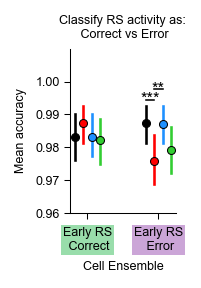

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_RS_Correct_v_Early_RS_Error'
ensemble_subset= ['Early_RS_Error', 'Early_RS_Correct']

fig_num= 3
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.96,1.01],
                                                    figsize = svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True)

#### supplemental fig 3- include WT CLNZ


In [ ]:
supp_svm_panel_size = (1.75,2)

switching posthoc comparison to include WT CLNZ
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_3\_21_Jul_2025\' already exists.
Saved 3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/3_Early_RS_Correct_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


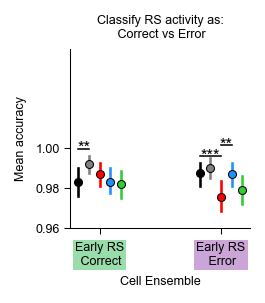

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_RS_Correct_v_Early_RS_Error'
ensemble_subset= ['Early_RS_Error', 'Early_RS_Correct']

fig_num= 3
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.96,1.05],
                                                    figsize = supp_svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True,
                                                   plot_config = geno_order_w_WT_CLNZ_no_eb)

## Figure 5
- early IA err vs. early RS err for early RS err ensemble
 Hypothesis: post-error activity in RS is too similar to post-error activity in IA

#### Early IA/RS Error- SVM accuracyfor Early RS Err Ensemble

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_5\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_5\_21_Jul_2025\' already exists.
Saved 5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


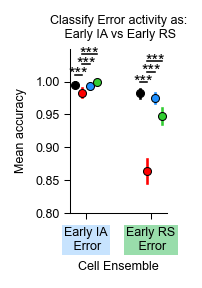

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Error_v_Early_RS_Error'
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error']
fig_num = 5
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.80,1.05],
                                                    figsize = (1.25,1.90),
                                                    fig_folder=fig_num)

#### Time-bin SVM Accuracy of early IA & RS err for early RS err ensemble

In [ ]:
#### plot time-dependent SVM  accuracy by bootstrap timebin
def plot_ensemble_value_at_timebin(ax_plot, timebin_values, ensemble, y_val, **kwargs):
    ''' Plot previouisly calculated time-bin bootstrapped activity cos sim for a given ensemble, for a given pair of classes to compare'''  
    trim_ticks = True
    #main plot 
    plot_df = timebin_values.loc[timebin_values.enriched_group == ensemble,:].dropna()
    #rename bin
    plot_df['bin_name'] = plot_df['bin_name'].str.replace(".0s to ", "-").str.replace(".0s", "").str.replace("--", "-")
    
    plot_params = {'data': plot_df,  'x': 'bin_name', 'y' : y_val, 'errorbar': ('pi', 75), 'errwidth': 1.25, 'order': plot_df['bin_name'].unique(),
                  **kwargs, **geno_color_dict_no_errorbar}
    sc = sns.pointplot(ax = ax_plot,**plot_params,  )#make cosine sim plot itself
    set_pointplot_edgecolor(sc, edge_color = 'black', linewidth = marker_edge_width)    # ax_plot.legend_.remove()
    ## NEW- trim tick values
    xticks = ax_plot.get_xticks()
    # find and return posthoc
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax_plot, plot_params, sc, preset_comparison_list, test_name = 'cohen_d',detect_error_bar = True)
    return posthoc_df

In [ ]:
time_decode_scores.bin_name.unique()

array(['-3.0s to -0.0s', '0.0s to 3.0s', '3.0s to 6.0s', '6.0s to 9.0s',
       '9.0s to 12.0s', '12.0s to 15.0s'], dtype=object)

In [ ]:
def plot_save_time_dep_decoding(decoding_df,decoding_col, decoder_comparison,ensemble, ylim = [0.825,1.04], figsize = (1.75,1.75),fig_num=5,verbose_title = True):
    fig, ax_plot = plt.subplots(1, 1, figsize = figsize, layout = 'constrained')

    time_decode_classes = decoding_df.loc[decoding_df[decoding_col] == decoder_comparison,:]
    posthoc_df = plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, 'mean_acc', dodge = True)
    #for plotting titles
    decoder_comparison_clean = decoder_comparison.replace("_", " ")
    ensemble_clean = ensemble.replace("_", " ")
    if verbose_title:
        ax_title = f'{ensemble_clean} ensemble:\nClassify {verbose_titles[decoder_comparison]}'
    else:
        ax_title = f'{ensemble_clean} ensemble:\n Decoding {decoder_comparison_clean}'
    set_ax_title_xlabel_ylabel(ax_plot, {'title':ax_title, 'legend_false':True,
                                             'xlabel': f"Decoded time window (s)", 'xtick_rotation':  {'rotation':30}, 'ylabel': 'Decoding Accuracy'})
    #axis info
    ax_plot.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.2f}"))
    # hand, labs =ax_plot.get_legend_handles_labels() #pull legend from final PCA object and delete it # fig.legend(hand, labs, bbox_to_anchor=(0.5, 1.0),loc = 'lower center', ncols = 4, frameon = False, title =None, )
    ##savefig
    fig_name = f'time-dep decoding - {ensemble_clean} ens- {decoder_comparison}'
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,f"{fig_num}",fig_name,csv_folder_most_recent, csv_folder_current_run,
                                    csv_suffix="posthoc_cohen_d",txt_suffix="posthoc_text")
    save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
    save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=stage_to_fig[(decoder_comparison,ensemble)],  filetypes_to_save = ['png', 'svg'])
    #new- save posthoc, CSV
    posthoc_df['plot_name'] = ax_title
    save_plot_record_as_csv_txt(posthoc_df,
                                f"{fig_num}",
                                fig_name,
                                csv_folder_most_recent, csv_folder_current_run,
                                csv_suffix="posthoc acc cohen D",txt_suffix="posthoc_text")
    return fig, ax_plot,posthoc_df 

In [ ]:
time_dep_panel_size = (1.75,1.75)

Saved 5_time-dep decoding - Early RS Error ens- Early_IA_Error_v_Early_RS_Error_posthoc_cohen_d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 5_time-dep decoding - Early RS Error ens- Early_IA_Error_v_Early_RS_Error_posthoc_cohen_d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/5_time-dep decoding - Early RS Error ens- Early_IA_Error_v_Early_RS_Error_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/5_time-dep decoding - Early RS Error ens- Early_IA_Error_v_Early_RS_Error_posthoc_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_5\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_5\_21_Jul_2025\' already exists.
Saved 5_time-dep decoding - Early RS Error ens-

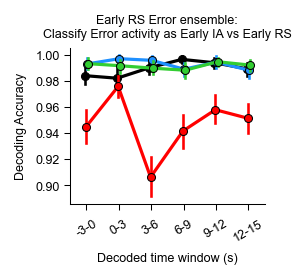

In [ ]:
ensemble = 'Early_RS_Error'
decoder_comparison = 'Early_IA_Error_v_Early_RS_Error'
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col, decoder_comparison,ensemble, ylim = [0.825,1.04], figsize = time_dep_panel_size,fig_num=5)
xticks = ax.get_xticklabels()
print(xticks)

#### F5 Supplement- Early IA vs RS Error SVM accuracy for all ensembles


The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_5\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_5\_21_Jul_2025\' has been created.


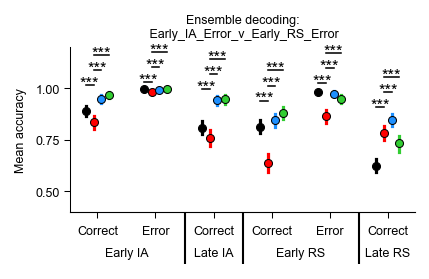

In [ ]:
fig, ax_plot = plt.subplots(1,1, figsize = (2.75,1.75), layout = 'constrained')
posthoc_svm_all_ens = plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col,
                                                         decoder_comparison, ax_plot)
fig_name = f'Ensemble SVM Decode Accuracy- all ens- {decoder_comparison}'
save_fig_as_filetype_list(fig, fig_name , subfolder_names, [ 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_5",  filetypes_to_save = ['png', 'svg'])

#### F5 supplement- include WT CLNZ in ensemble accuracy comparison

switching posthoc comparison to include WT CLNZ
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_5\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_5\_21_Jul_2025\' already exists.
Saved s_5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved s_5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/s_5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/s_5_Early_IA_Error_v_Early_RS_Error SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


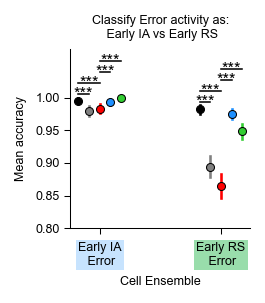

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Error_v_Early_RS_Error'
ensemble_subset = ['Early_IA_Error', 'Early_RS_Error']
fig_num = 's_5'
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.82,1.075],
                                                    figsize = supp_svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True,
                                                   plot_config = geno_order_w_WT_CLNZ_no_eb)

## Figure 6- early IA Correct vs. early RS Correct for early RS Correct ensemble
Hypothesis: after early RS correct trials, representations of the IA rule are inappropriately re-recruited 

#### Early IA/RS Correct - SVM accuracy for Early RS Err Ensemble

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_6\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_6\_21_Jul_2025\' already exists.
Saved 6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


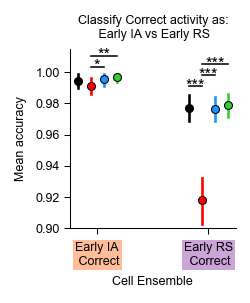

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct'
ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct']
fig_num = 6

fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison, ylim = [0.9, 1.015],
                                ensemble_subset= ensemble_subset,
                               fig_folder=fig_num)

#### early IA & RS correct for early RS err ensemble SVM accuracy 

Saved 6_time-dep decoding - Early RS Correct ens- Early_IA_Correct_v_Early_RS_Correct_posthoc_cohen_d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 6_time-dep decoding - Early RS Correct ens- Early_IA_Correct_v_Early_RS_Correct_posthoc_cohen_d_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/6_time-dep decoding - Early RS Correct ens- Early_IA_Correct_v_Early_RS_Correct_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/6_time-dep decoding - Early RS Correct ens- Early_IA_Correct_v_Early_RS_Correct_posthoc_text_21_Jul_2025.txt
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_6\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_6\_21_Jul_2025\' already exists.
Saved 6_time-dep decodi

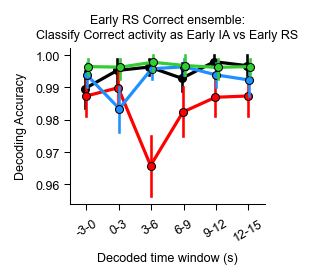

In [ ]:
ensemble ='Early_RS_Correct'
decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct'
fig, ax,posthoc_df= plot_save_time_dep_decoding(time_decode_scores,decoding_col, decoder_comparison,ensemble, ylim = [0.825,1.04], figsize = (1.75,1.75),fig_num=6)

#### F6 Supplement- SVM accuracy for all ensembles


The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_6\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_6\_21_Jul_2025\' already exists.


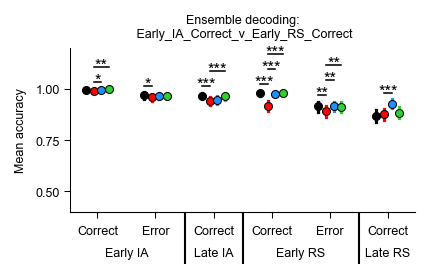

In [ ]:
fig, ax_plot = plt.subplots(1,1, figsize = (2.75,1.75), layout = 'constrained')
posthoc_svm_all_ens = plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col, decoder_comparison, ax_plot)
##save

fig_name = f'Ensemble SVM decode acc- all ens- {decoder_comparison}'
save_fig_as_filetype_list(fig, fig_name  , subfolder_names, [ 'svg', 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_{stage_to_fig[(decoder_comparison,ensemble)]}",  filetypes_to_save = ['png', 'svg'])

#### F6 supplement- include WT CLNZ in ensemble accuracy comparison

switching posthoc comparison to include WT CLNZ
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_6\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_6\_21_Jul_2025\' already exists.
Saved s_6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved s_6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/s_6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/s_6_Early_IA_Correct_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


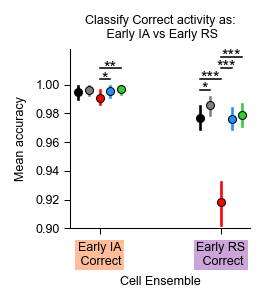

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Correct_v_Early_RS_Correct'
ensemble_subset = ['Early_IA_Correct', 'Early_RS_Correct']
fig_num = 's_6'
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.9,1.025],
                                                    figsize = supp_svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True,
                                                   plot_config = geno_order_w_WT_CLNZ_no_eb)

## Figure 7- Early IA Correct vs. Late IA in Late IA ensemble
Hypothesis: Why is early RS corr and early IA corr activity overly-similar?  Does this reflect hyperstability of early IA corr activity manifesting before the early RS period, or does this originate during the early RS period?

####  Early IA Correct vs. Late IA in Late IA ensemble - SVM accuracy

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_7\_21_Jul_2025\' already exists.
Saved 7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


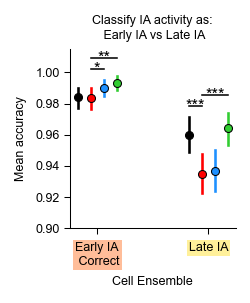

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Correct_v_Late_IA'
ensemble_subset = ['Early_IA_Correct', 'Late_IA']
fig_num = 7
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset,
                               fig_folder=fig_num)

#### Supp.-  Early IA Correct vs. Late IA SVM accuracy for all ensembles


The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\_21_Jul_2025\' has been created.


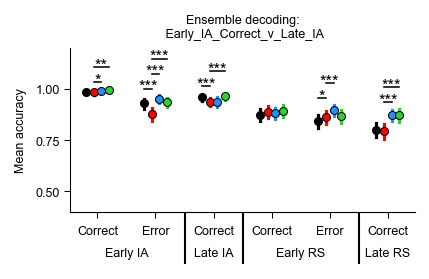

In [ ]:
fig, ax_plot = plt.subplots(1,1, figsize = (2.75,1.75), layout = 'constrained')
posthoc_svm_all_ens = plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col, decoder_comparison='Early_IA_Correct_v_Late_IA', ax_plot=ax_plot)
#save
fig_name = f'Ensemble SVM Decode accuracy- all ens- {decoder_comparison}'
save_fig_as_filetype_list(fig, fig_name  , subfolder_names, [ 'svg', 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_7",  filetypes_to_save = ['png', 'svg'])

#### Supp- Early IA Corr vs Late IA SVM with WT CLNZ

switching posthoc comparison to include WT CLNZ
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\_21_Jul_2025\' already exists.
Saved s_7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved s_7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/s_7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/s_7_Early_IA_Correct_v_Late_IA SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


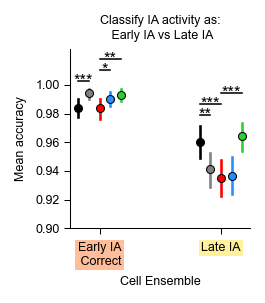

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_IA_Correct_v_Late_IA'
ensemble_subset = ['Early_IA_Correct', 'Late_IA']
fig_num = 's_7'
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.9,1.025],
                                                    figsize = supp_svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True,
                                                   plot_config = geno_order_w_WT_CLNZ_no_eb)

####  Early RS Correct vs. Late IA in Early RS Correct ensemble - SVM accuracy

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\fig_7\_21_Jul_2025\' already exists.
Saved 7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved 7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


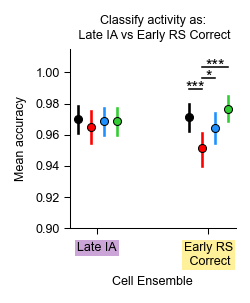

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Late_IA_v_Early_RS_Correct'
ensemble_subset = ['Early_RS_Correct', 'Late_IA']
fig_num = 7
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset,
                               fig_folder=fig_num)

#### Early RS Correct vs. Late IA Time-bin SVM Accuracy in Early RS Correct ensemble 

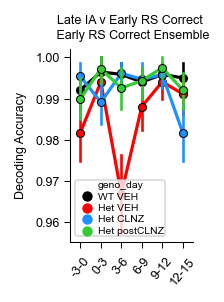

In [ ]:
fig, ax_plot = plt.subplots(1, 1, figsize = fig_size_panel, layout = 'constrained')
ensemble ='Early_RS_Correct'
time_decode_classes = time_decode_scores.loc[time_decode_scores[decoding_col] == decoder_comparison,:]
plot_ensemble_value_at_timebin(ax_plot, time_decode_classes, ensemble, 'mean_acc')
#for plotting titles
decoder_comparison_clean = decoder_comparison.replace("_", " ")
ensemble_clean = ensemble.replace("_", " ")
set_ax_title_xlabel_ylabel(ax_plot, {'title':f'{decoder_comparison_clean} \n {ensemble_clean} Ensemble',
                                         'xlabel': None, 'xtick_rotation': {'rotation': 50}, 'ylabel': 'Decoding Accuracy'})


#### Supp.- Late IA vs Early RS Correct SVM accuracy for all ensembles


The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\_21_Jul_2025\' already exists.


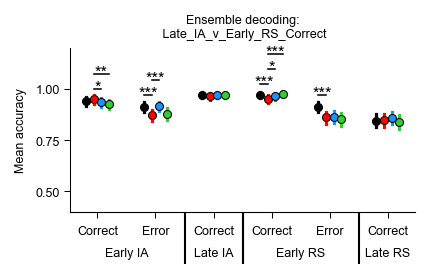

In [ ]:
fig, ax_plot = plt.subplots(1,1, figsize = (2.75,1.75), layout = 'constrained')
posthoc_svm_all_ens = plot_decode_accuracy_all_ensembles(pop_mean_decoding, decoding_col, decoder_comparison='Late_IA_v_Early_RS_Correct', ax_plot=ax_plot)
#save
fig_name = f'Ensemble SVM accuracy- all ens- {decoder_comparison}'
save_fig_as_filetype_list(fig, fig_name  , subfolder_names, [ 'svg', 'pdf', 'png'])
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key=f"s_{stage_to_fig[(decoder_comparison,ensemble)]}",  filetypes_to_save = ['png', 'svg'])

#### Supp- Early RS Corr vs Late IA SVM with WT CLNZ

switching posthoc comparison to include WT CLNZ
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\_21_Jul_2025\' already exists.
Saved s_7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved s_7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/s_7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/s_7_Late_IA_v_Early_RS_Correct SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


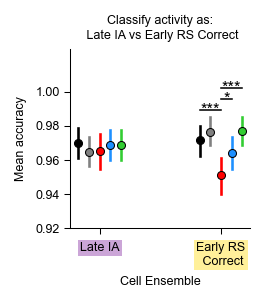

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Late_IA_v_Early_RS_Correct'
ensemble_subset = ['Early_RS_Correct', 'Late_IA']
fig_num = 's_7'
fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset, ylim = [0.92,1.025],
                                                    figsize = supp_svm_panel_size,
                                                    fig_folder=fig_num,
                                                    verbose_title = True,
                                                   plot_config = geno_order_w_WT_CLNZ_no_eb)

## SUPP/ not included: Figure s/8- Early RS Correct vs. Late RS in Early RS Correct / Late RS ensemble
Hypothesis: RS rule related activity is too unstable -

####  Early RS Correct / Late RS ensemble - SVM accuracy

The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\' already exists.
The folder '\My Drive\Colab Notebooks\Current Figures and Panels\supp_fig_7\_21_Jul_2025\' already exists.
Saved s_7_Early_RS_Correct_v_Late_RS SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/
Saved s_7_Early_RS_Correct_v_Late_RS SVM accuracy by ensem_posthoc decode acc cohen D_21_Jul_2025.csv to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/analysis_CSV_storage_21_Jul_2025/s_7_Early_RS_Correct_v_Late_RS SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt
Output saved to G:/My Drive/Colab Notebooks/Run Outputs/most_recent_analysis_CSV_storage/s_7_Early_RS_Correct_v_Late_RS SVM accuracy by ensem_posthoc_text_21_Jul_2025.txt


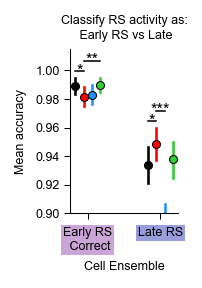

In [ ]:
decoding_col = 'classes decoded'
decoder_comparison = 'Early_RS_Correct_v_Late_RS'
ensemble_subset = ['Early_RS_Correct', 'Late_RS']
fig_num = "s_7"

fig, ax,posthoc_df= plot_save_ensemble_svm_accuracy(decoding_df = pop_mean_decoding,
                                decoder_comparison= decoder_comparison,
                                ensemble_subset= ensemble_subset,
                                                    figsize = svm_panel_size,
                                                    fig_folder=fig_num)

In [ ]:

import math
def get_cohen_d_CI(cohen_d, n_array, ci_type = '95'):
    """TO- given cohen d, and ci type, find CI limitsusing Hedge and Olkin formula"""
    z = {'95': 1.96, '99': 2.58}[ci_type] 
    summed_n = np.sum(n_array)
    product_n = np.prod(n_array)
    hedge_olkin_sigma = np.sqrt((summed_n/product_n)+((cohen_d**2)/(2*summed_n)))
    ci_range = z*hedge_olkin_sigma
    ci_lims = [cohen_d-ci_range, cohen_d+ci_range]
    return ci_lims
def get_pvalue_from_CI(estimate, ci_lims,ci_type = '95'):
    """TO- given CI limits, find pvalue. Based off Altman & Bland 2011:  https://doi.org/10.1136/bmj.d2304"""
    ci_lims = np.array(ci_lims)
    ci_range = ci_lims.max() - ci_lims.min()    
    #  1 calculate the standard error given normality assumption: SE = (u − l)/(2×1.96)
    z = {'95': 1.96, '99': 2.58}[ci_type] 
    se = ci_range/(2*z)
    # 2 calculate the margin of error: MOE = 1.96SE
    estimate_zscore = estimate/se 
    # 3 calculate the p-value: p = exponent(-0.717*estimate_zscore - 0.416*estimate_zscore**2)
    pval = math.exp(-0.717*estimate_zscore - 0.416*estimate_zscore**2)
    return pval
